In [1110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

In [1111]:
warnings.filterwarnings('ignore')

## Load dataset with the animals disease

In [1112]:
animals = pd.read_csv('./cleaned_animal_disease_prediction.csv')

In [1113]:
animals.head()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection


## EDA + ANALISYS

In [1114]:
animals.info()

<class 'pandas.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Animal_Type         431 non-null    str    
 1   Breed               431 non-null    str    
 2   Age                 431 non-null    int64  
 3   Gender              431 non-null    str    
 4   Weight              431 non-null    float64
 5   Symptom_1           431 non-null    str    
 6   Symptom_2           431 non-null    str    
 7   Symptom_3           431 non-null    str    
 8   Symptom_4           431 non-null    str    
 9   Duration            431 non-null    str    
 10  Appetite_Loss       431 non-null    str    
 11  Vomiting            431 non-null    str    
 12  Diarrhea            431 non-null    str    
 13  Coughing            431 non-null    str    
 14  Labored_Breathing   431 non-null    str    
 15  Lameness            431 non-null    str    
 16  Skin_Lesions       

In [1115]:
animals.describe()

,Age,Weight,Heart_Rate
count,431.000000,431.000000,431.000000
mean,5.044084,214.441067,105.582367
std,2.553685,259.594305,27.892936
min,1.000000,1.000000,70.000000
25%,3.000000,8.000000,80.000000
50%,5.000000,80.000000,92.000000
75%,6.000000,500.000000,130.000000
max,16.000000,850.000000,165.000000


## Duplicates Check

In [1116]:
animals[animals.duplicated()]

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction
421,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,No,39.5°C,120,Parvovirus
422,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,No,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection
423,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,No,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease
424,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,Yes,No,No,No,No,No,No,39.2°C,130,Gastroenteritis
425,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection
426,Horse,Thoroughbred,6,Female,500.0,Coughing,Labored Breathing,Nasal Discharge,Fever,10 days,...,No,Yes,Yes,No,No,Yes,No,39.8°C,85,Equine Influenza
427,Dog,German Shepherd,3,Female,30.0,Lameness,Fever,Skin Lesions,Lethargy,7 days,...,No,No,No,Yes,Yes,No,No,39.3°C,110,Lyme Disease
428,Cat,Maine Coon,2,Male,6.0,Vomiting,Appetite Loss,Lethargy,Diarrhea,4 days,...,Yes,No,No,No,No,No,No,39.1°C,140,Intestinal Parasites
429,Dog,Bulldog,5,Male,23.0,Labored Breathing,Coughing,Nasal Discharge,Appetite Loss,6 days,...,No,Yes,Yes,No,No,Yes,No,40.0°C,115,Canine Distemper
430,Cow,Jersey,4,Female,580.0,Lethargy,Decreased Milk Yield,Fever,No,8 days,...,No,No,No,No,No,No,No,39.6°C,70,Mastitis


In [1117]:
animals.drop(animals[animals.duplicated()].index, inplace=True)

In [1118]:
animals[animals.duplicated()]

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction


## MISSING VALUES

In [1119]:
animals.isna().sum()

Animal_Type           0
Breed                 0
Age                   0
Gender                0
Weight                0
Symptom_1             0
Symptom_2             0
Symptom_3             0
Symptom_4             0
Duration              0
Appetite_Loss         0
Vomiting              0
Diarrhea              0
Coughing              0
Labored_Breathing     0
Lameness              0
Skin_Lesions          0
Nasal_Discharge       0
Eye_Discharge         0
Body_Temperature      0
Heart_Rate            0
Disease_Prediction    0
dtype: int64

## Target analisys

In [1120]:
animals['Disease_Prediction'].unique()

<StringArray>
[                     'Parvovirus',     'Upper Respiratory Infection',
          'Foot and Mouth Disease',                 'Gastroenteritis',
                'Fungal Infection',                'Equine Influenza',
                    'Lyme Disease',            'Intestinal Parasites',
                'Canine Distemper',                        'Mastitis',
 ...
             'African Swine Fever',       'Viral Hemorrhagic Disease',
                 'Scrapie Disease',   'Feline Immunodeficiency Virus',
                 'Bovine Mastitis',                        'Goat Pox',
 'Porcine Epidemic Diarrhea Virus',     'Canine Infectious Hepatitis',
      'Feline Panleukopenia Virus',      'Porcine Circovirus Disease']
Length: 139, dtype: str

## Each feature research

In [1121]:
animals['Animal_Type'].unique()

<StringArray>
['Dog', 'Cat', 'Cow', 'Horse', 'Rabbit', 'Sheep', 'Goat', 'Pig']
Length: 8, dtype: str

In [1122]:
animals['Body_Temperature'].unique()

<StringArray>
['39.5°C', '38.9°C', '40.1°C', '39.2°C', '38.7°C', '39.8°C', '39.3°C',
 '39.1°C', '40.0°C', '39.6°C', '39.0°C', '39.4°C', '38.8°C', '39.9°C',
 '39.7°C', '38.6°C', '40.2°C', '38.5°C', '38.4°C']
Length: 19, dtype: str

In [1123]:
animals[animals['Animal_Type'] == 'Dog']['Breed'].unique()

<StringArray>
[          'Labrador',             'Beagle',    'German Shepherd',
            'Bulldog',             'Poodle',          'Chihuahua',
     'Siberian Husky',   'Golden Retriever',          'Dachshund',
              'Husky',      'Border Collie', 'Labrador Retriever',
         'Rottweiler',           'Shih Tzu',          'Dalmatian',
              'Akita',              'Boxer',              'Corgi',
  'Doberman Pinscher',           'Pit Bull',     'Cocker Spaniel',
  'Yorkshire Terrier']
Length: 22, dtype: str

In [1124]:
animals['Duration'].unique()

<StringArray>
[ '3 days',  '1 week',  '5 days',  '2 days', '2 weeks', '10 days',  '7 days',
  '4 days',  '6 days',  '8 days',  '9 days', '12 days']
Length: 12, dtype: str

## Visual research

In [1125]:
plot_params = {
    'figure.facecolor': 'lightgray', 
    'axes.edgecolor': 'black', 
    'text.color': '.10', 
    'axes.labelcolor': '.10', 
    'patch.edgecolor': 'black', 
    'grid.color': 'black'
}

sns.set_style('whitegrid', rc=plot_params)
sns.set_palette('hsv')

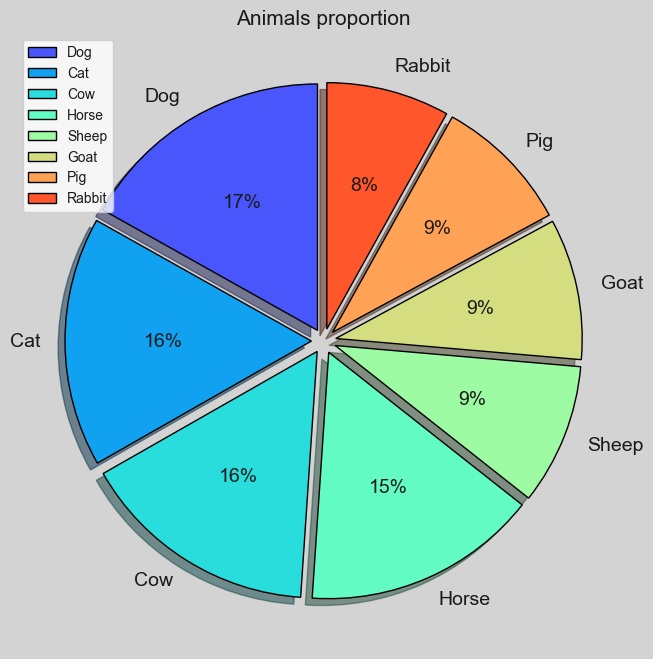

In [1126]:
plt.figure(figsize=(10, 8))

plt.subplot()
animals_by_type = np.round(animals['Animal_Type'].value_counts() / animals.shape[0] * 100, 2)
plt.pie(
    animals_by_type, 
    labels=animals_by_type.index, 
    autopct='%.0f%%', 
    colors=sns.color_palette('rainbow', n_colors=len(animals_by_type.index)), 
    explode=[0.05] * animals_by_type.shape[0], 
    shadow=True,
    startangle=90.0,
    textprops={'fontsize': 14}
)
plt.title('Animals proportion', fontsize=15)
plt.legend()

# plt.savefig('animals_proportions_ver_2.png')
plt.show()

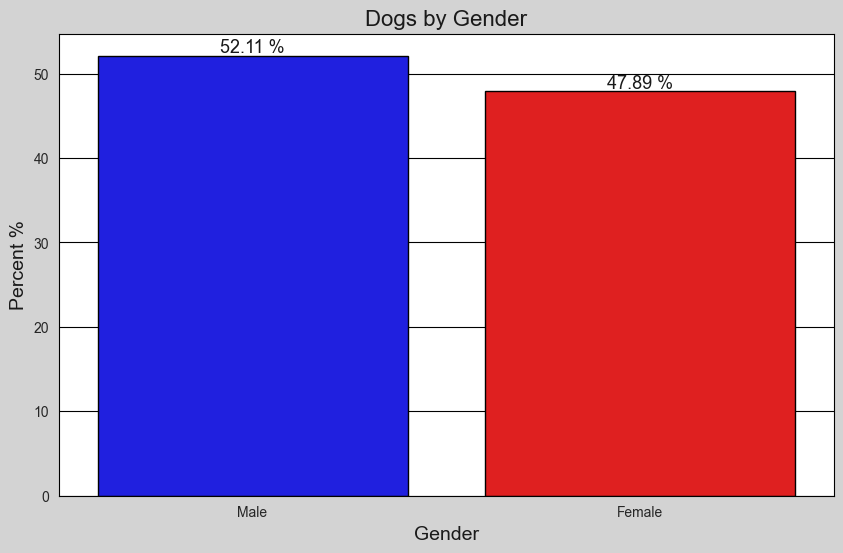

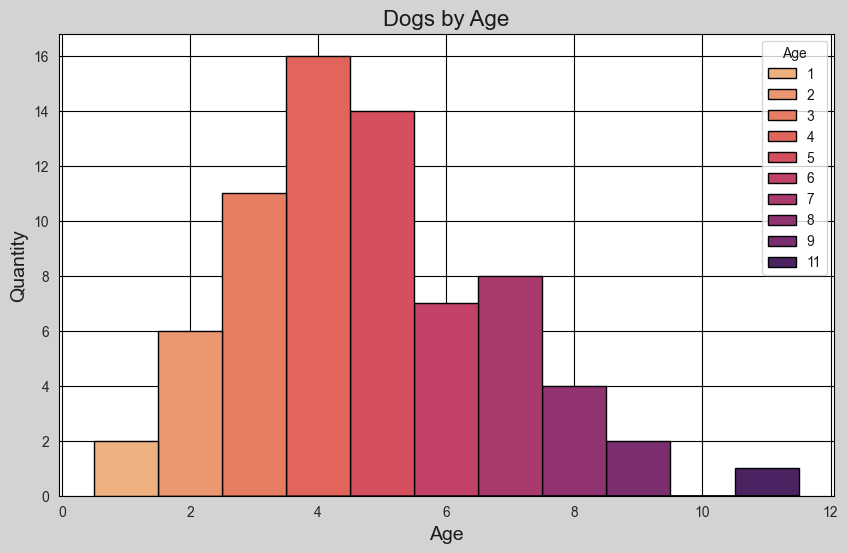

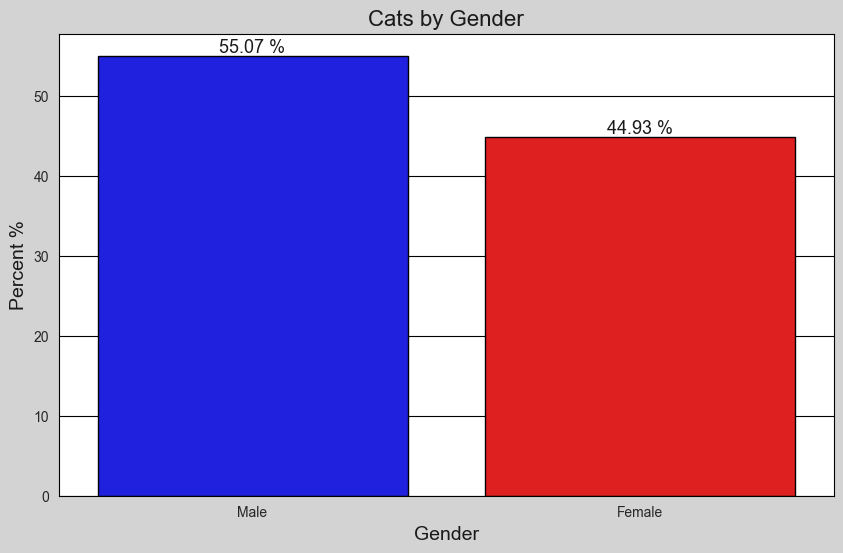

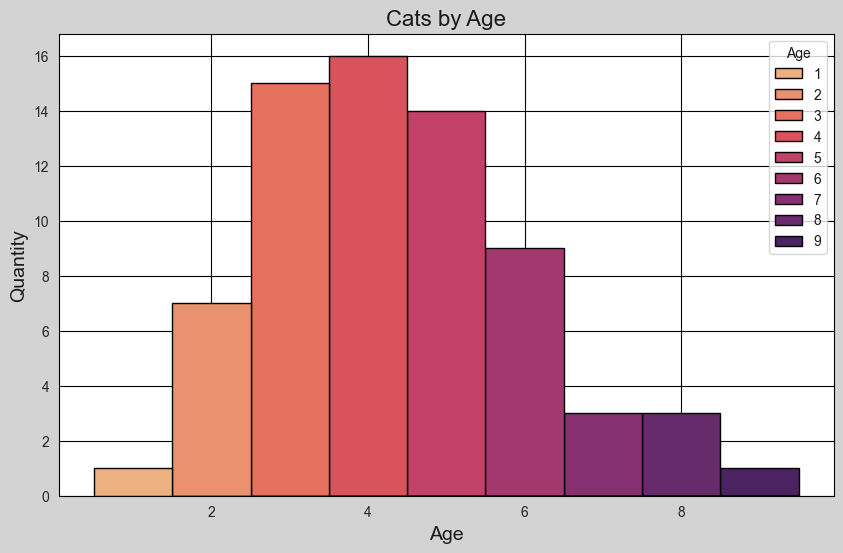

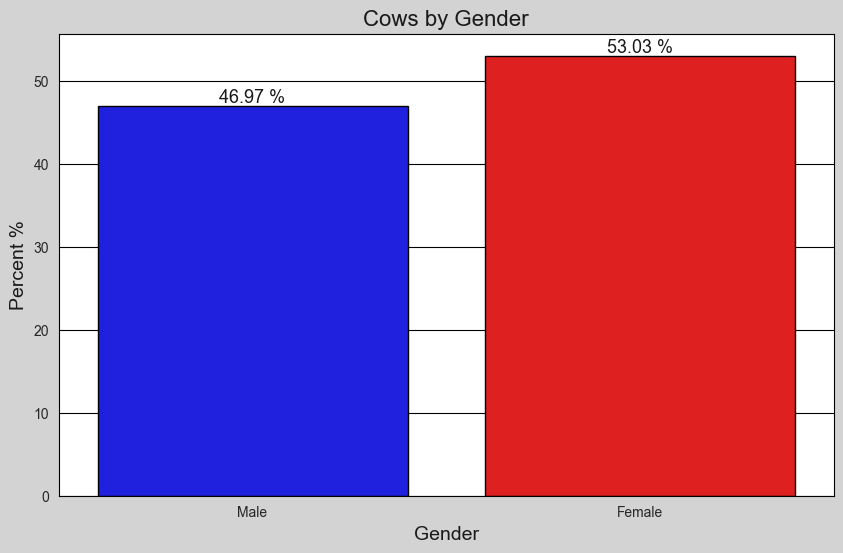

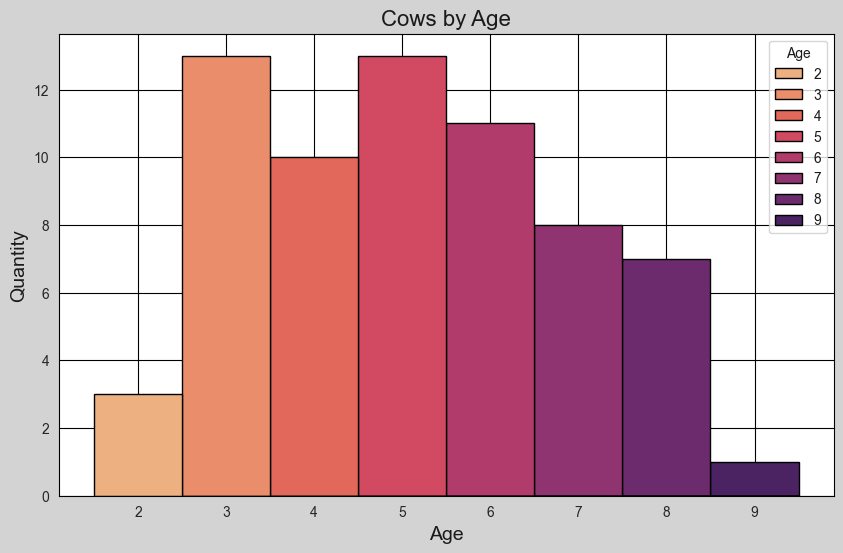

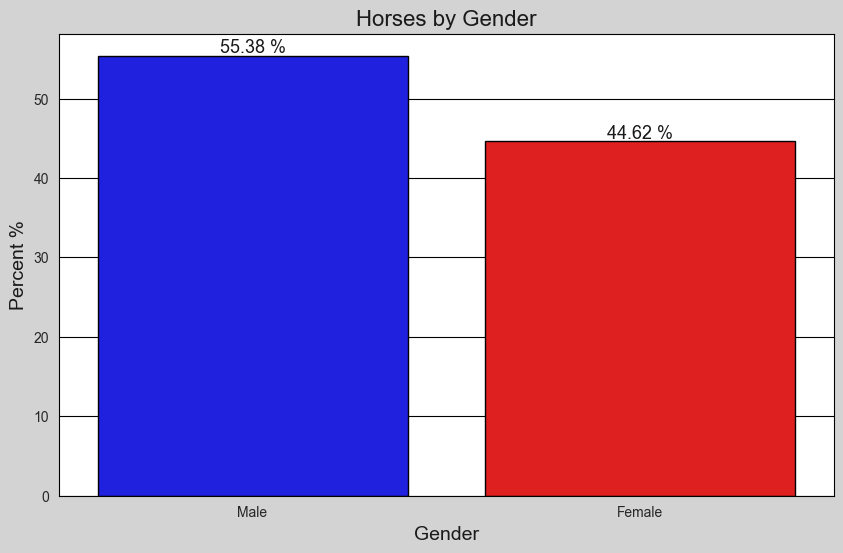

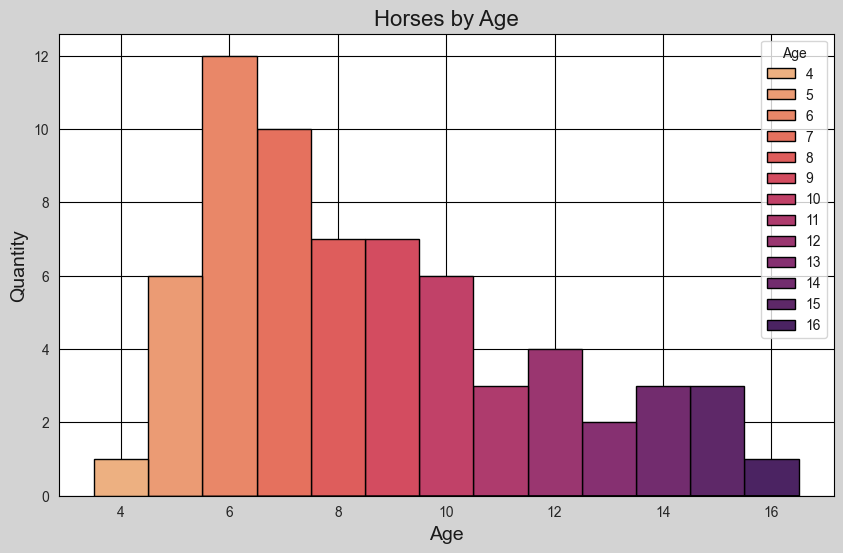

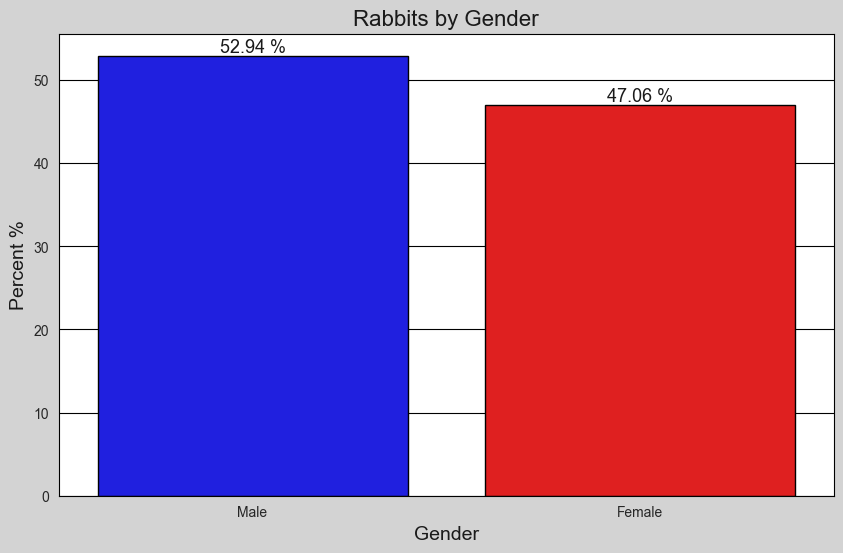

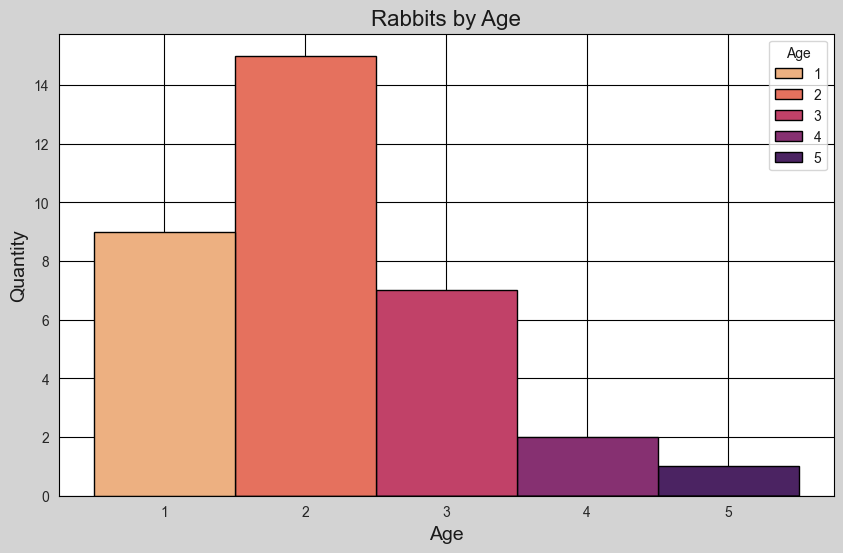

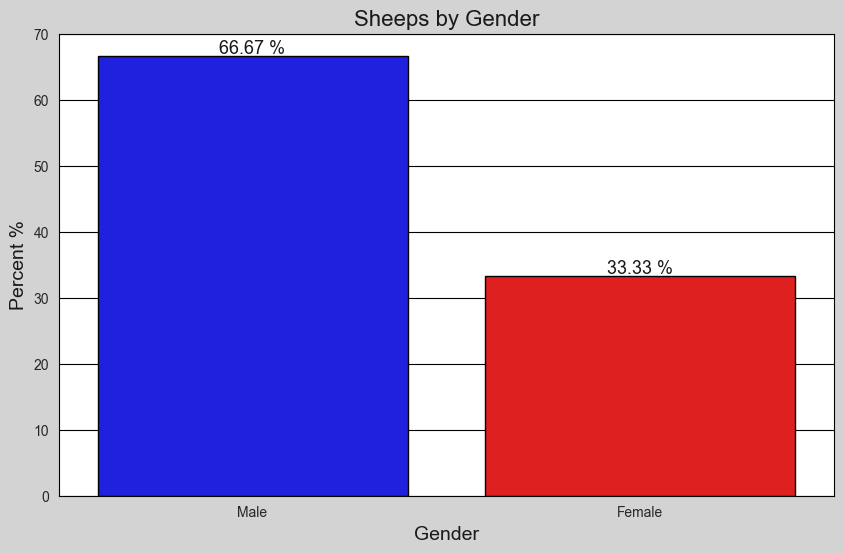

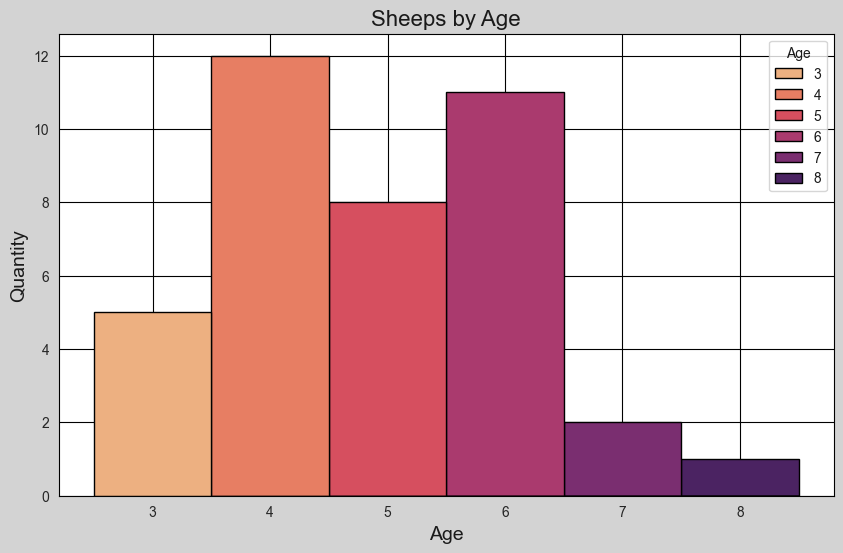

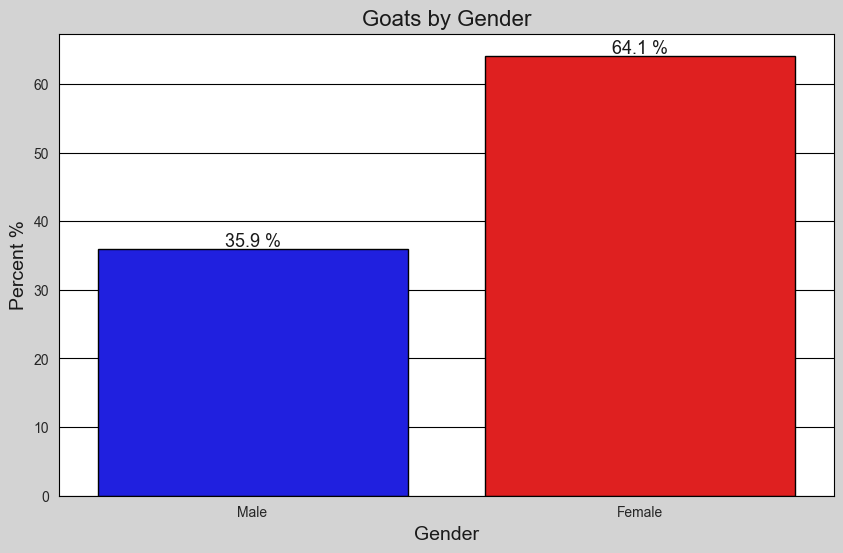

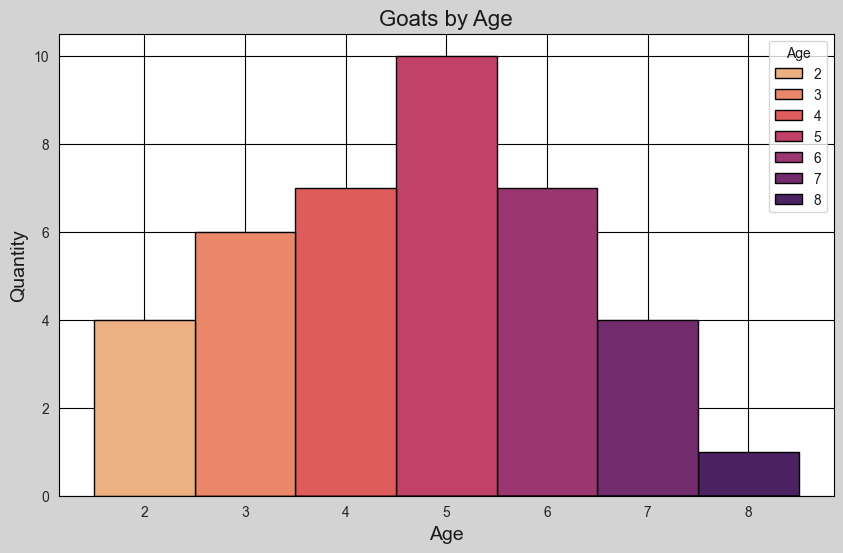

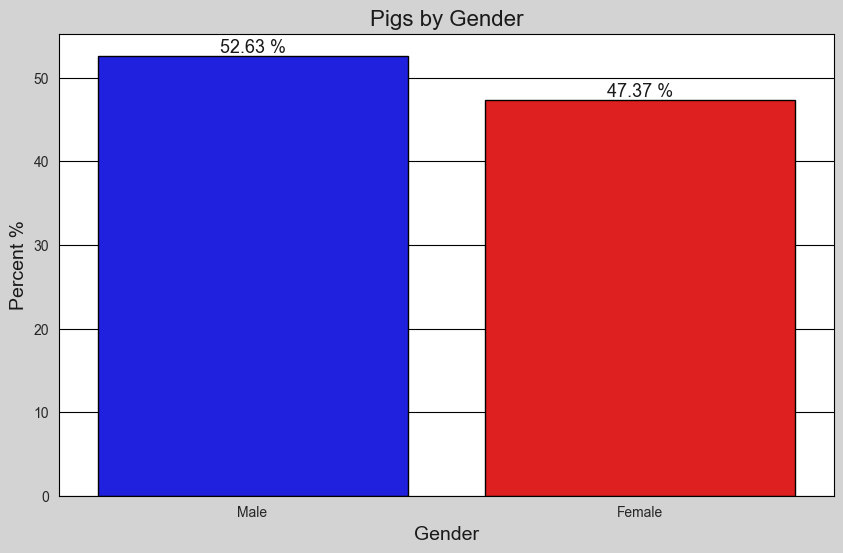

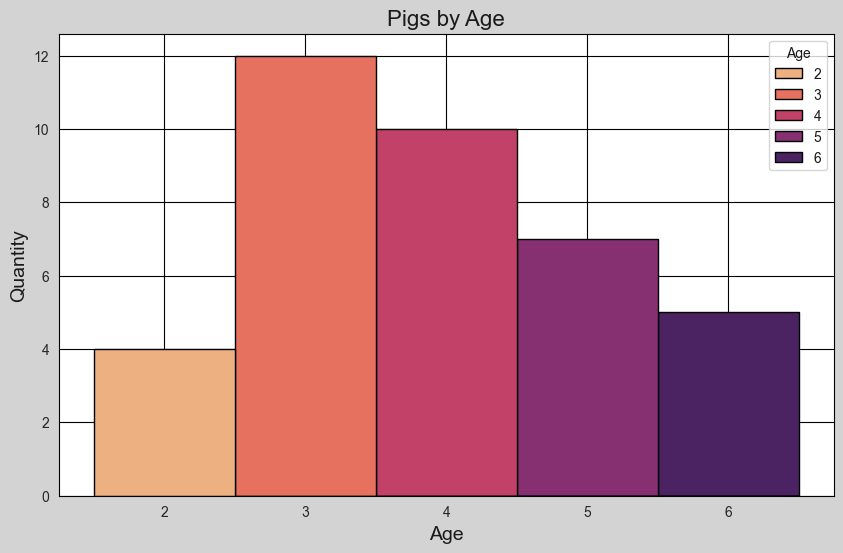

In [1127]:
for gen in animals['Animal_Type'].unique():
    a_group = animals[animals['Animal_Type'] == gen]
    plt.figure(figsize=(10, 6))

    plt.subplot()
    ax = sns.countplot(a_group, x='Gender', stat='percent', order=['Male', 'Female'], palette=['blue', 'red'])
    gender = np.round(a_group['Gender'].value_counts().sort_index(ascending=False) / a_group.shape[0] * 100, 2)
    i = 0
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x()
        ax.text(x=x + p.get_width() / 2, y=height + 0.4, s=f'{gender.values[i]} %', ha='center', fontsize=13)
        i += 1
    
    plt.xlabel('Gender', fontsize=14)
    plt.ylabel('Percent %', fontsize=14)

    plt.title(f'{gen}s by Gender', fontsize=16)

    # plt.savefig(f'{gen}_gender_stat.png', transparent=True)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.subplot()

    sns.histplot(a_group, x='Age', hue='Age', palette='flare', discrete=True, alpha=1.0)
    plt.title(f'{gen}s by Age', fontsize=16)
    plt.xlabel('Age', fontsize=14)
    plt.ylabel('Quantity', fontsize=14)

    # plt.savefig(f'{gen}_age_stat.png', transparent=True)
    plt.show()

## Feature Engineering

In [1128]:
animals['Duration_in_days'] = animals['Duration'].apply(func=lambda x: int(''.join([c for c in x if c.isdigit()])) if 'days' in x else int(''.join([c for c in x if c.isdigit()])) * 7)
animals.head()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Duration,...,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Body_Temperature,Heart_Rate,Disease_Prediction,Duration_in_days
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,3 days,...,No,No,No,No,No,No,39.5°C,120,Parvovirus,3
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,1 week,...,Yes,No,No,No,Yes,Yes,38.9°C,150,Upper Respiratory Infection,7
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,5 days,...,Yes,Yes,No,No,Yes,No,40.1°C,90,Foot and Mouth Disease,5
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,2 days,...,No,No,No,No,No,No,39.2°C,130,Gastroenteritis,2
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,2 weeks,...,No,No,No,Yes,No,No,38.7°C,160,Fungal Infection,14


In [1129]:
animals['Body_Temperature_°C'] = animals['Body_Temperature'].apply(func=lambda x: float(x[:4]))
animals.drop(['Duration', 'Body_Temperature'], axis=1, inplace=True)
animals.head()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Appetite_Loss,...,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Heart_Rate,Disease_Prediction,Duration_in_days,Body_Temperature_°C
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite Loss,Vomiting,Yes,...,No,No,No,No,No,No,120,Parvovirus,3,39.5
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye Discharge,Nasal Discharge,No,...,Yes,No,No,No,Yes,Yes,150,Upper Respiratory Infection,7,38.9
2,Cow,Holstein,3,Female,600.0,Fever,Nasal Discharge,Labored Breathing,Coughing,Yes,...,Yes,Yes,No,No,Yes,No,90,Foot and Mouth Disease,5,40.1
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite Loss,Yes,...,No,No,No,No,No,No,130,Gastroenteritis,2,39.2
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite Loss,Skin Lesions,No,Yes,...,No,No,No,Yes,No,No,160,Fungal Infection,14,38.7


### Check for unique disease instatnces

In [1130]:
dogs = animals[animals['Animal_Type'] == 'Dog']
dogs.groupby('Breed')['Disease_Prediction'].value_counts()

Breed               Disease_Prediction         
Akita               Canine Hepatitis               1
Beagle              Kennel Cough                   2
                    Canine Distemper               2
                    Gastroenteritis                2
                    Canine Influenza               1
                    Distemper                      1
                    Canine Leptospirosis           1
Border Collie       Bordetella Infection           1
Boxer               Canine Infectious Hepatitis    1
                    Canine Leptospirosis           1
                    Gastroenteritis                1
Bulldog             Canine Cough                   1
                    Gastroenteritis                1
                    Canine Leptospirosis           1
                    Kennel Cough                   1
                    Canine Distemper               1
Chihuahua           Canine Parvovirus              3
                    Parvovirus                     

### All symptoms output 

In [1131]:
s1 = np.array(animals['Symptom_1'].unique())
s2 = np.array(animals['Symptom_2'].unique())
s3 = np.array(animals['Symptom_3'].unique())
s4 = np.array(animals['Symptom_4'].unique())
common = set(np.concat((s1, s2, s3, s4)))
common

{'Appetite Loss',
 'Coughing',
 'Decreased Milk Yield',
 'Dehydration',
 'Diarrhea',
 'Eye Discharge',
 'Fever',
 'Labored Breathing',
 'Lameness',
 'Lethargy',
 'Loss of Appetite',
 'Nasal Discharge',
 'No',
 'Reduced Appetite',
 'Reduced Milk Production',
 'Reduced Mobility',
 'Reduced Wool Growth',
 'Reduced Wool Production',
 'Skin Lesions',
 'Sneezing',
 'Swelling',
 'Swollen Joints',
 'Swollen Legs',
 'Vomiting',
 'Weight Loss'}

In [1132]:
animals.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal_Type          421 non-null    str    
 1   Breed                421 non-null    str    
 2   Age                  421 non-null    int64  
 3   Gender               421 non-null    str    
 4   Weight               421 non-null    float64
 5   Symptom_1            421 non-null    str    
 6   Symptom_2            421 non-null    str    
 7   Symptom_3            421 non-null    str    
 8   Symptom_4            421 non-null    str    
 9   Appetite_Loss        421 non-null    str    
 10  Vomiting             421 non-null    str    
 11  Diarrhea             421 non-null    str    
 12  Coughing             421 non-null    str    
 13  Labored_Breathing    421 non-null    str    
 14  Lameness             421 non-null    str    
 15  Skin_Lesions         421 non-null    str    
 16  N

In [1133]:
def symptom_change(r):
    if r == 'No':
        return r
    elif r in ('Appetite Loss', 'Loss of Appetite', 'Reduced Appetite'):
        return 'Appetite_Loss'
    elif r in ('Swelling', 'Swollen Joints', 'Swollen Legs'):
        return 'Swelling'
    elif r in ('Decreased Milk Yield', 'Reduced Milk Production'):
        return 'Milk_Reduce'
    elif r in ('Reduced Wool Growth', 'Reduced Wool Production'):
        return 'Wool_Reduce'
    elif r == 'Reduced Mobility':
        return 'Lethargy'
    else:
        return r.replace(' ', '_')

for col in animals.columns[5:9]:
    animals[col] = animals[col].map(func=symptom_change)

In [1134]:
s1 = np.array(animals['Symptom_1'].unique())
s2 = np.array(animals['Symptom_2'].unique())
s3 = np.array(animals['Symptom_3'].unique())
s4 = np.array(animals['Symptom_4'].unique())
common = set(np.concat((s1, s2, s3, s4)))
common

{'Appetite_Loss',
 'Coughing',
 'Dehydration',
 'Diarrhea',
 'Eye_Discharge',
 'Fever',
 'Labored_Breathing',
 'Lameness',
 'Lethargy',
 'Milk_Reduce',
 'Nasal_Discharge',
 'No',
 'Skin_Lesions',
 'Sneezing',
 'Swelling',
 'Vomiting',
 'Weight_Loss',
 'Wool_Reduce'}

In [1135]:
for symp in common:
    if symp == 'No':
        continue
    else:
        if symp in animals.columns:
            animals[symp] = animals.apply(func=lambda r: 'Yes' if symp in (r['Symptom_1'], r['Symptom_2'], r['Symptom_3'], r['Symptom_4']) else r[symp], axis=1)
        else:
            animals[symp] = animals.apply(func=lambda r: 'Yes' if symp in (r['Symptom_1'], r['Symptom_2'], r['Symptom_3'], r['Symptom_4']) else 'No', axis=1)

In [1136]:
animals.head()

,Animal_Type,Breed,Age,Gender,Weight,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Appetite_Loss,...,Duration_in_days,Body_Temperature_°C,Fever,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce
0,Dog,Labrador,4,Male,25.0,Fever,Lethargy,Appetite_Loss,Vomiting,Yes,...,3,39.5,Yes,No,Yes,No,No,No,No,No
1,Cat,Siamese,2,Female,4.5,Coughing,Sneezing,Eye_Discharge,Nasal_Discharge,No,...,7,38.9,No,Yes,No,No,No,No,No,No
2,Cow,Holstein,3,Female,600.0,Fever,Nasal_Discharge,Labored_Breathing,Coughing,Yes,...,5,40.1,Yes,No,No,No,No,No,No,No
3,Dog,Beagle,1,Male,10.0,Diarrhea,Vomiting,Lethargy,Appetite_Loss,Yes,...,2,39.2,No,No,Yes,No,No,No,No,No
4,Cat,Persian,5,Male,3.8,Lethargy,Appetite_Loss,Skin_Lesions,No,Yes,...,14,38.7,No,No,Yes,No,No,No,No,No


In [1137]:
animals.drop(columns=['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4'], inplace=True)

### Reconstruct dataset

In [1138]:
features = animals.loc[:, ['Duration_in_days', 'Heart_Rate', 'Body_Temperature_°C', 'Disease_Prediction']]
features

,Duration_in_days,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,3,120,39.5,Parvovirus
1,7,150,38.9,Upper Respiratory Infection
2,5,90,40.1,Foot and Mouth Disease
3,2,130,39.2,Gastroenteritis
4,14,160,38.7,Fungal Infection
...,...,...,...,...
416,4,110,39.2,Canine Parvovirus
417,5,100,39.2,Canine Parvovirus
418,4,110,39.1,Feline Calicivirus
419,7,110,39.4,Equine Infectious Anemia


In [1139]:
animals.drop(columns=['Duration_in_days', 'Heart_Rate', 'Body_Temperature_°C', 'Disease_Prediction'], inplace=True)
new_an = pd.concat([animals, features], axis=1)
new_an.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal_Type          421 non-null    str    
 1   Breed                421 non-null    str    
 2   Age                  421 non-null    int64  
 3   Gender               421 non-null    str    
 4   Weight               421 non-null    float64
 5   Appetite_Loss        421 non-null    str    
 6   Vomiting             421 non-null    str    
 7   Diarrhea             421 non-null    str    
 8   Coughing             421 non-null    str    
 9   Labored_Breathing    421 non-null    str    
 10  Lameness             421 non-null    str    
 11  Skin_Lesions         421 non-null    str    
 12  Nasal_Discharge      421 non-null    str    
 13  Eye_Discharge        421 non-null    str    
 14  Fever                421 non-null    str    
 15  Sneezing             421 non-null    str    
 16  L

In [1140]:
new_an.head()

,Animal_Type,Breed,Age,Gender,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,...,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Duration_in_days,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,Dog,Labrador,4,Male,25.0,Yes,Yes,No,No,No,...,Yes,No,No,No,No,No,3,120,39.5,Parvovirus
1,Cat,Siamese,2,Female,4.5,No,No,No,Yes,No,...,No,No,No,No,No,No,7,150,38.9,Upper Respiratory Infection
2,Cow,Holstein,3,Female,600.0,Yes,No,No,Yes,Yes,...,No,No,No,No,No,No,5,90,40.1,Foot and Mouth Disease
3,Dog,Beagle,1,Male,10.0,Yes,Yes,Yes,No,No,...,Yes,No,No,No,No,No,2,130,39.2,Gastroenteritis
4,Cat,Persian,5,Male,3.8,Yes,No,No,No,No,...,Yes,No,No,No,No,No,14,160,38.7,Fungal Infection


### Transform symptoms columns into numerical type

In [1141]:
for col in new_an.iloc[:, 5:22].columns:
    new_an[col] = new_an[col].map(func=lambda x: 1 if x == 'Yes' else 0)

In [1142]:
new_an.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal_Type          421 non-null    str    
 1   Breed                421 non-null    str    
 2   Age                  421 non-null    int64  
 3   Gender               421 non-null    str    
 4   Weight               421 non-null    float64
 5   Appetite_Loss        421 non-null    int64  
 6   Vomiting             421 non-null    int64  
 7   Diarrhea             421 non-null    int64  
 8   Coughing             421 non-null    int64  
 9   Labored_Breathing    421 non-null    int64  
 10  Lameness             421 non-null    int64  
 11  Skin_Lesions         421 non-null    int64  
 12  Nasal_Discharge      421 non-null    int64  
 13  Eye_Discharge        421 non-null    int64  
 14  Fever                421 non-null    int64  
 15  Sneezing             421 non-null    int64  
 16  L

### Disease statistic for each type of animal

In [1143]:
sns.set_style('white', rc=plot_params.update({'axis.grid': False}))

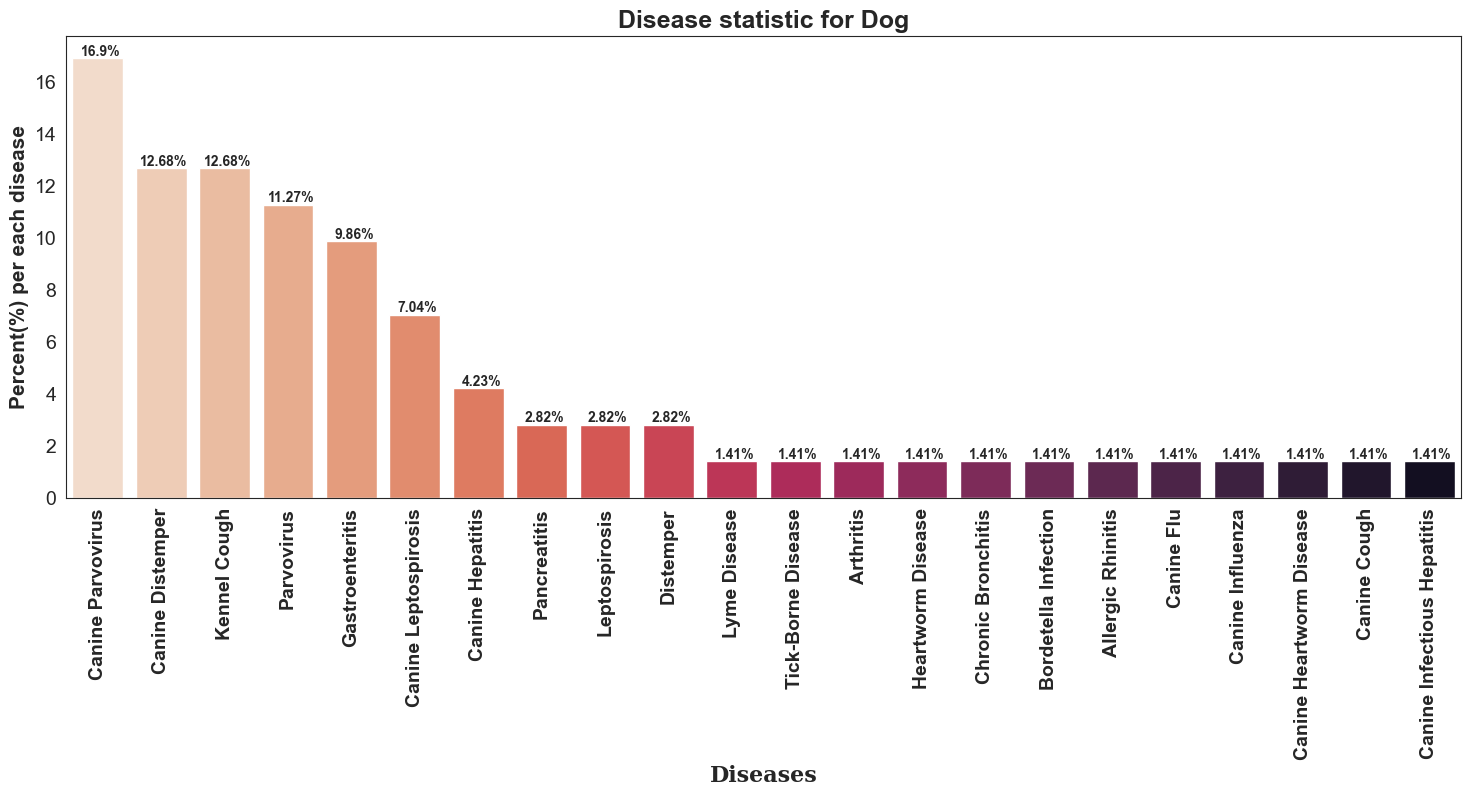

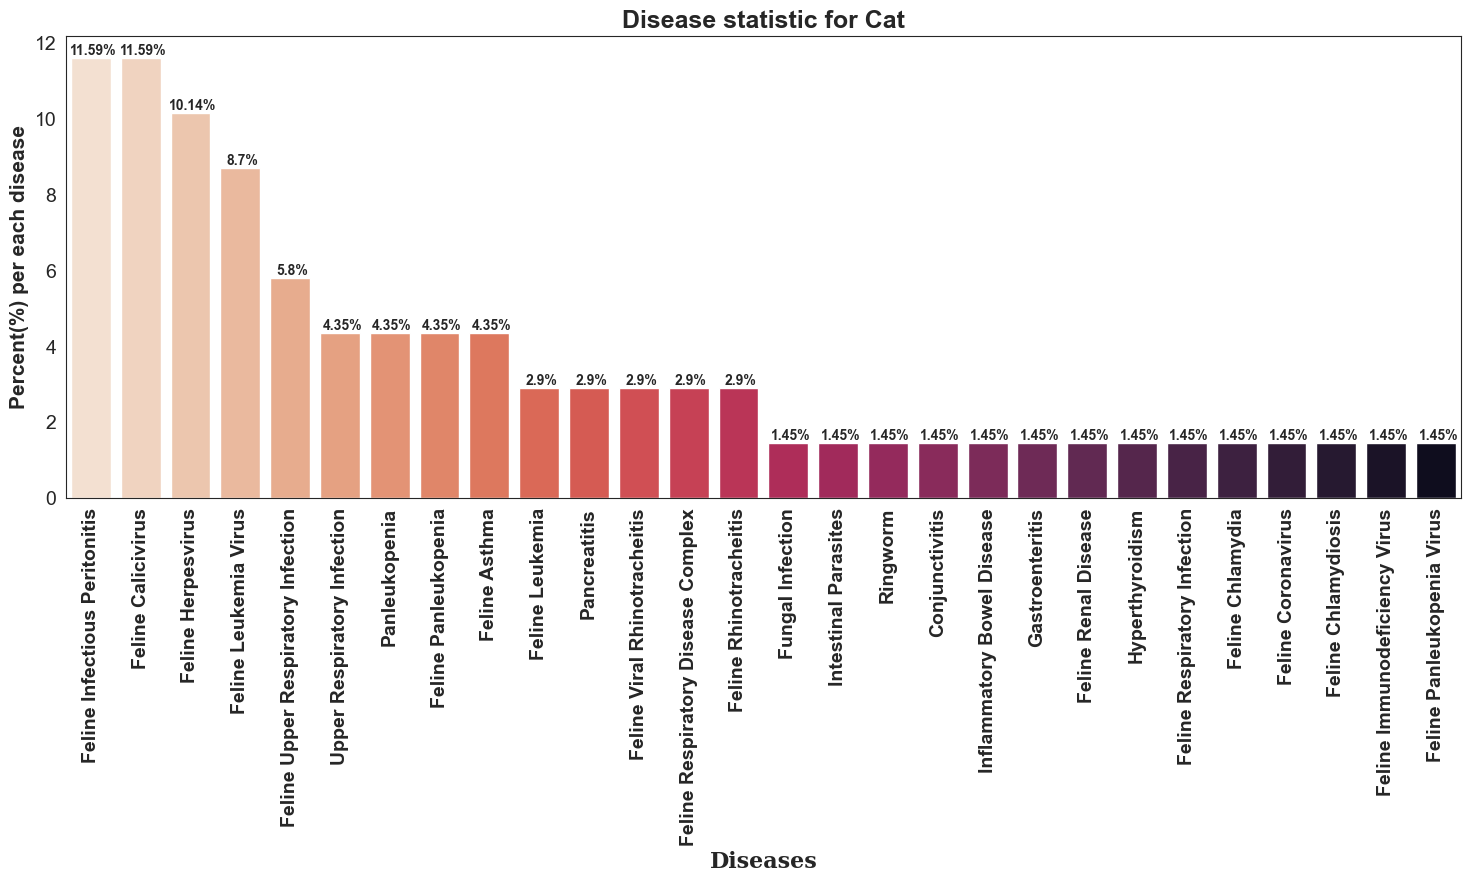

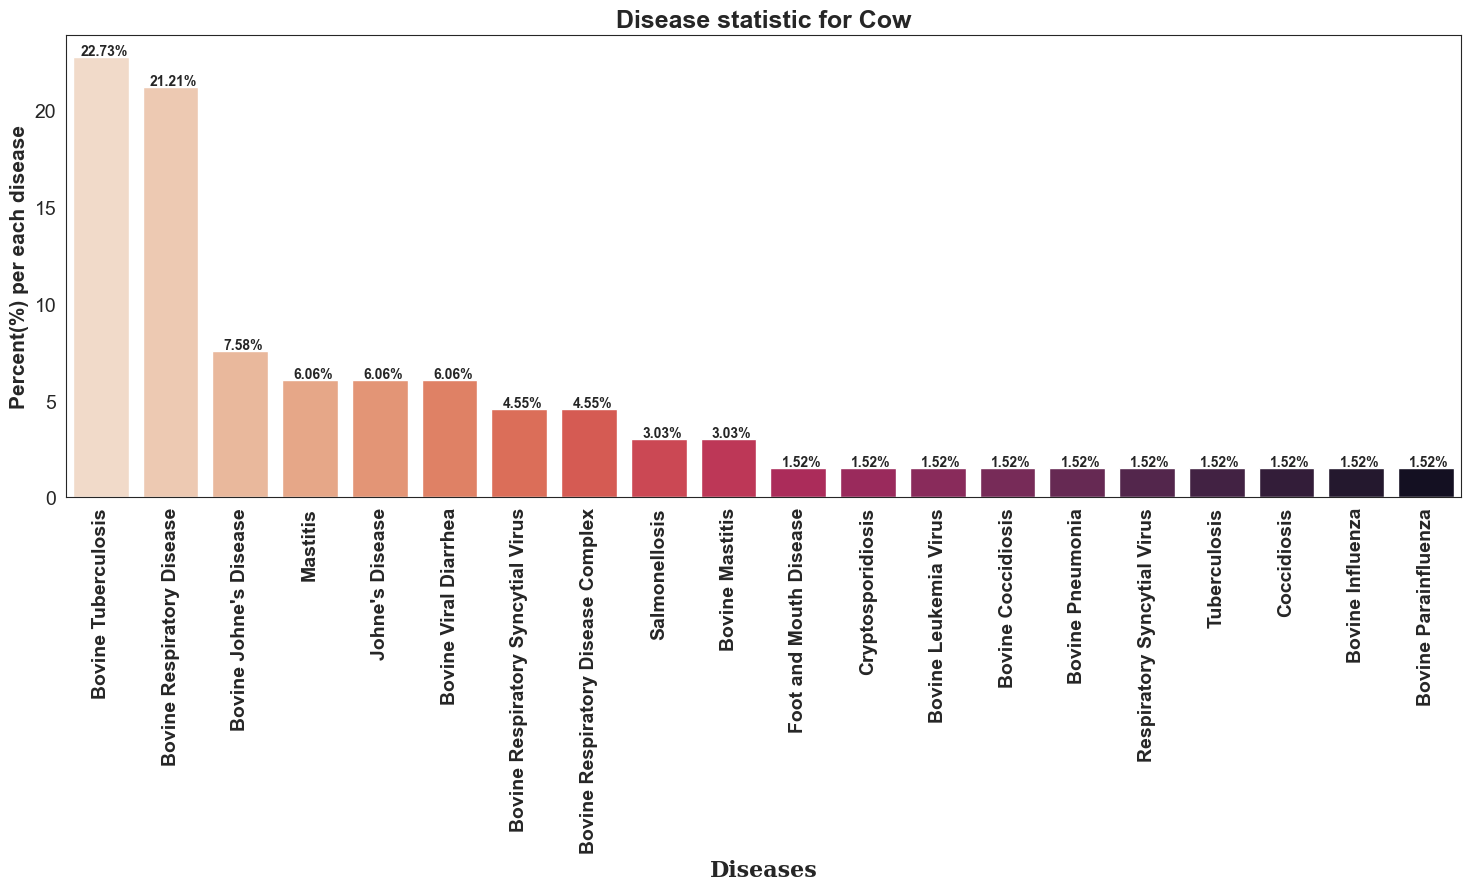

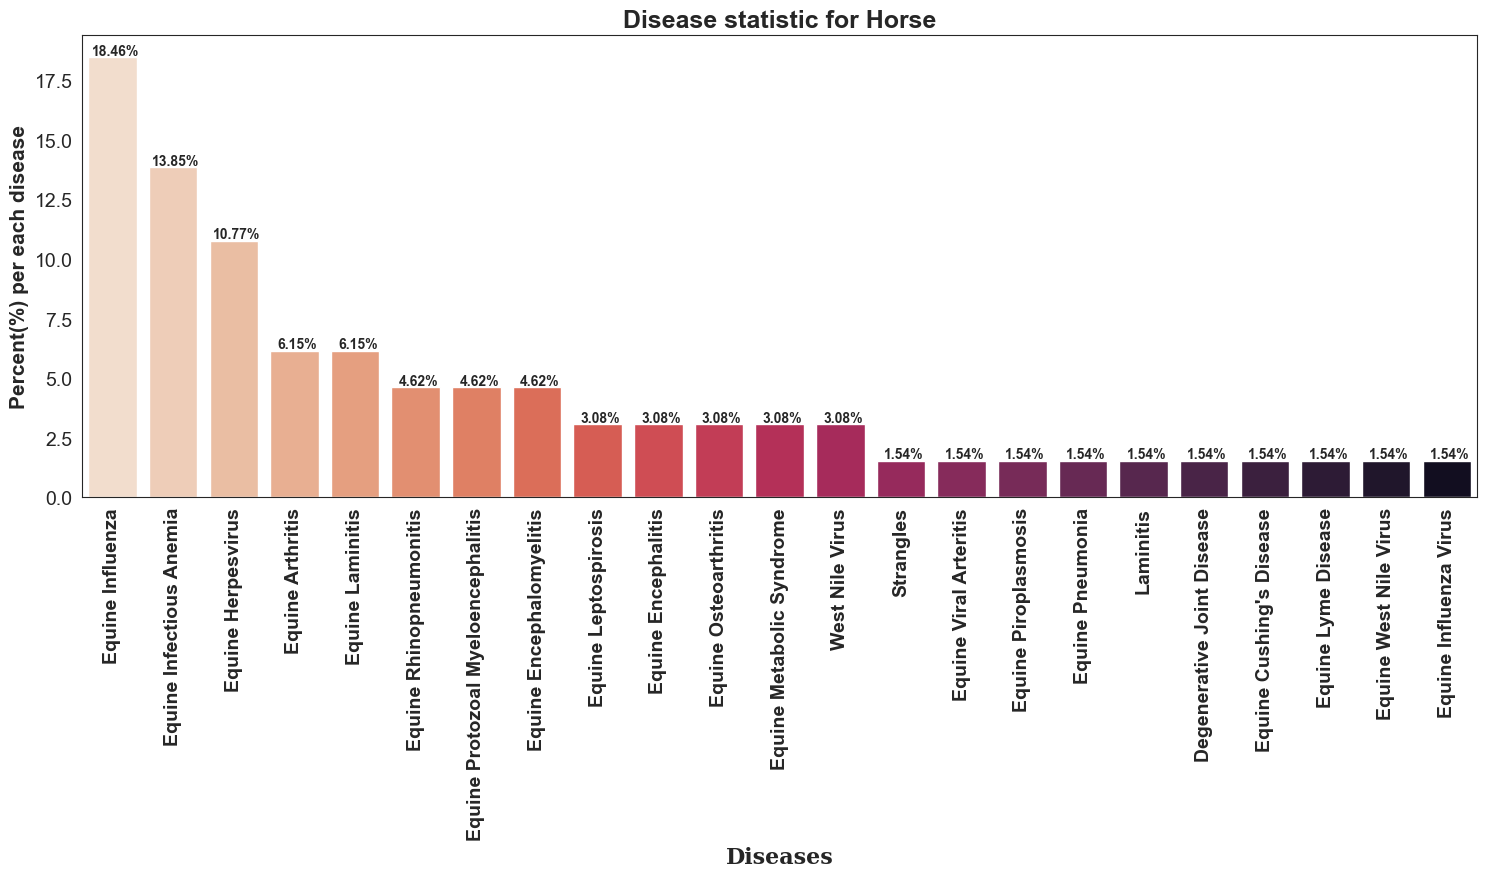

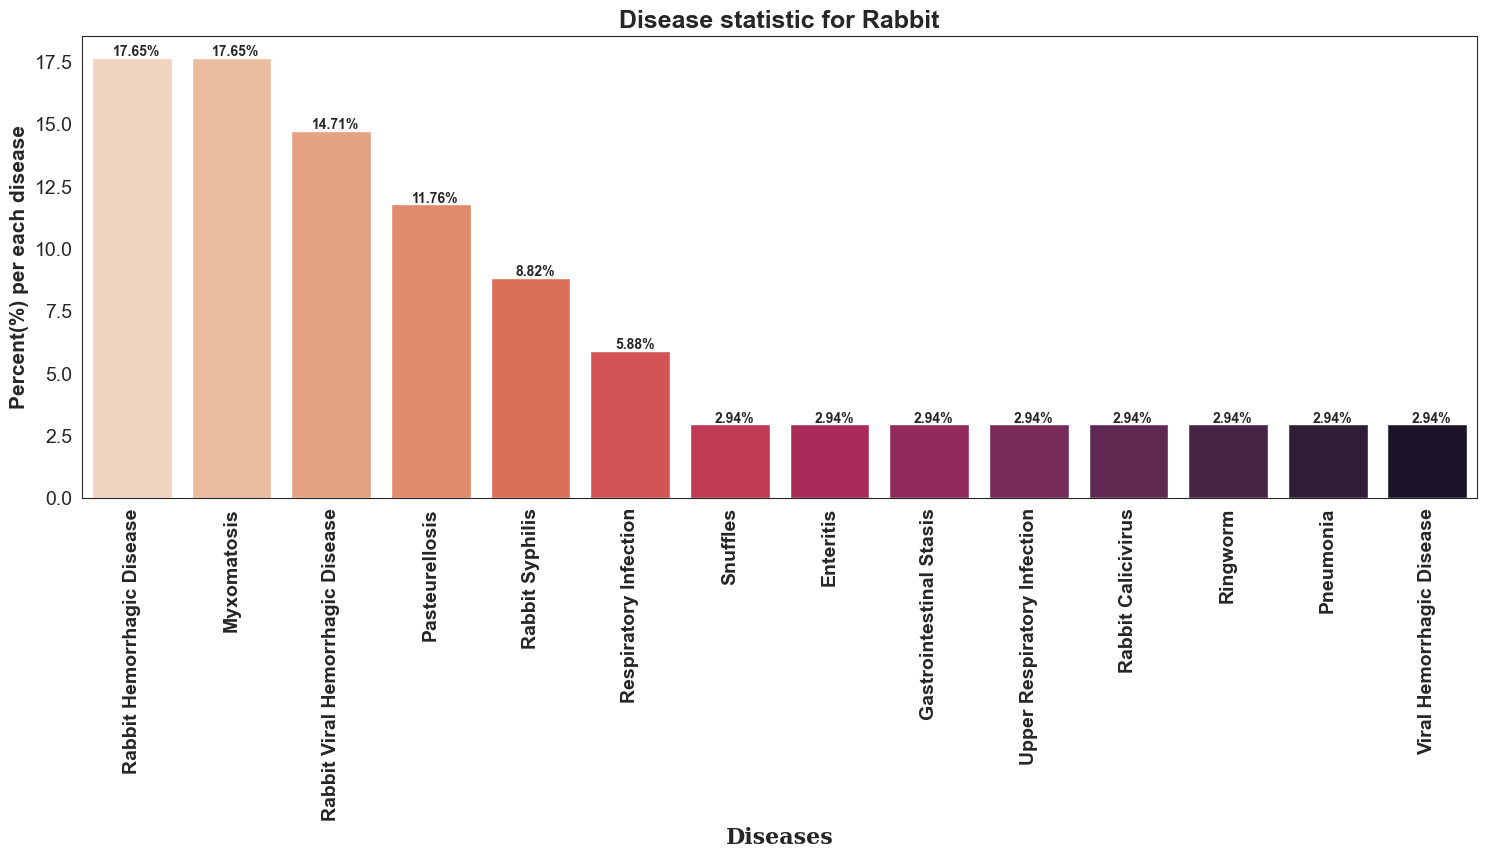

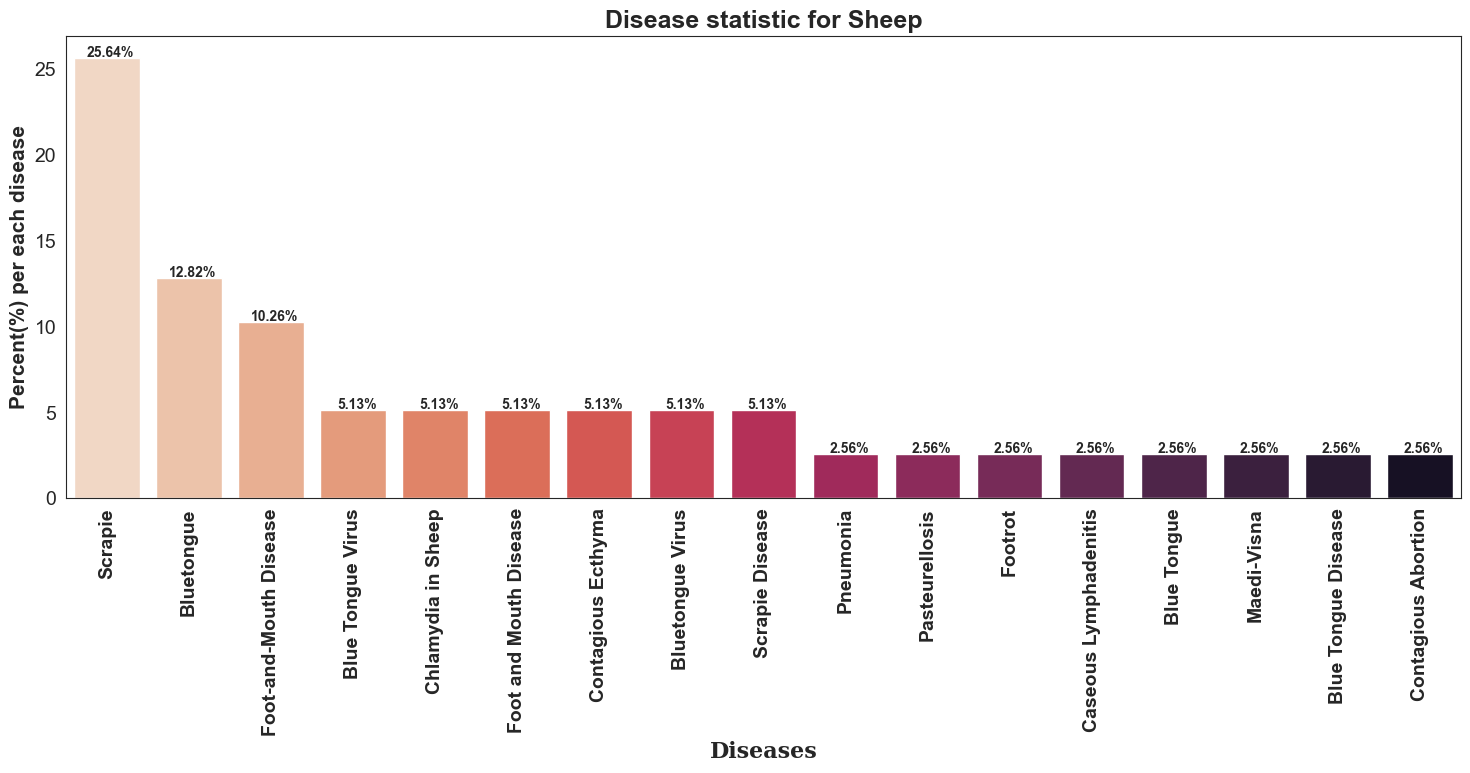

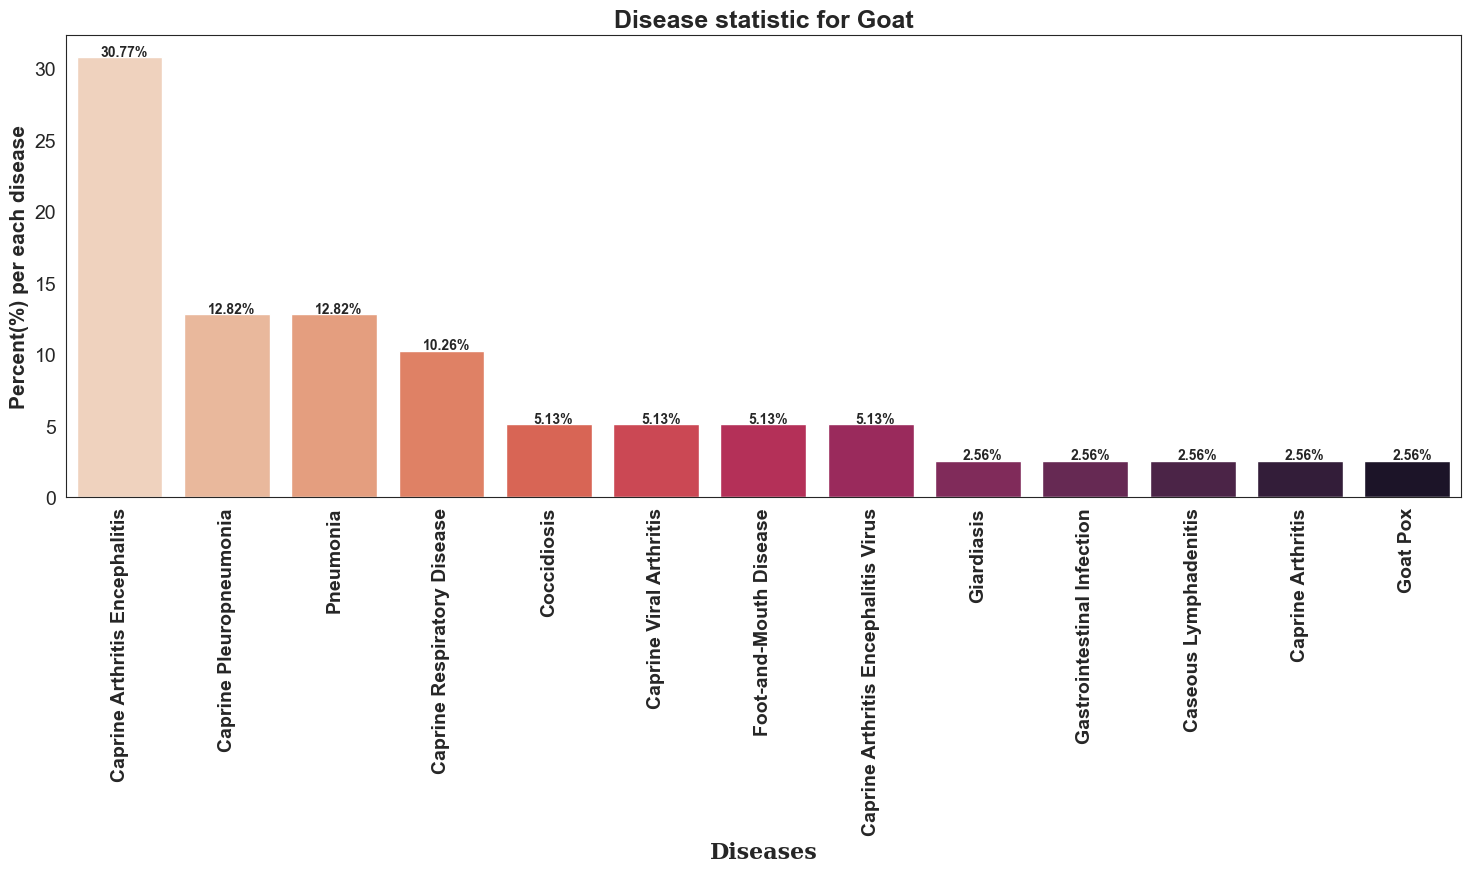

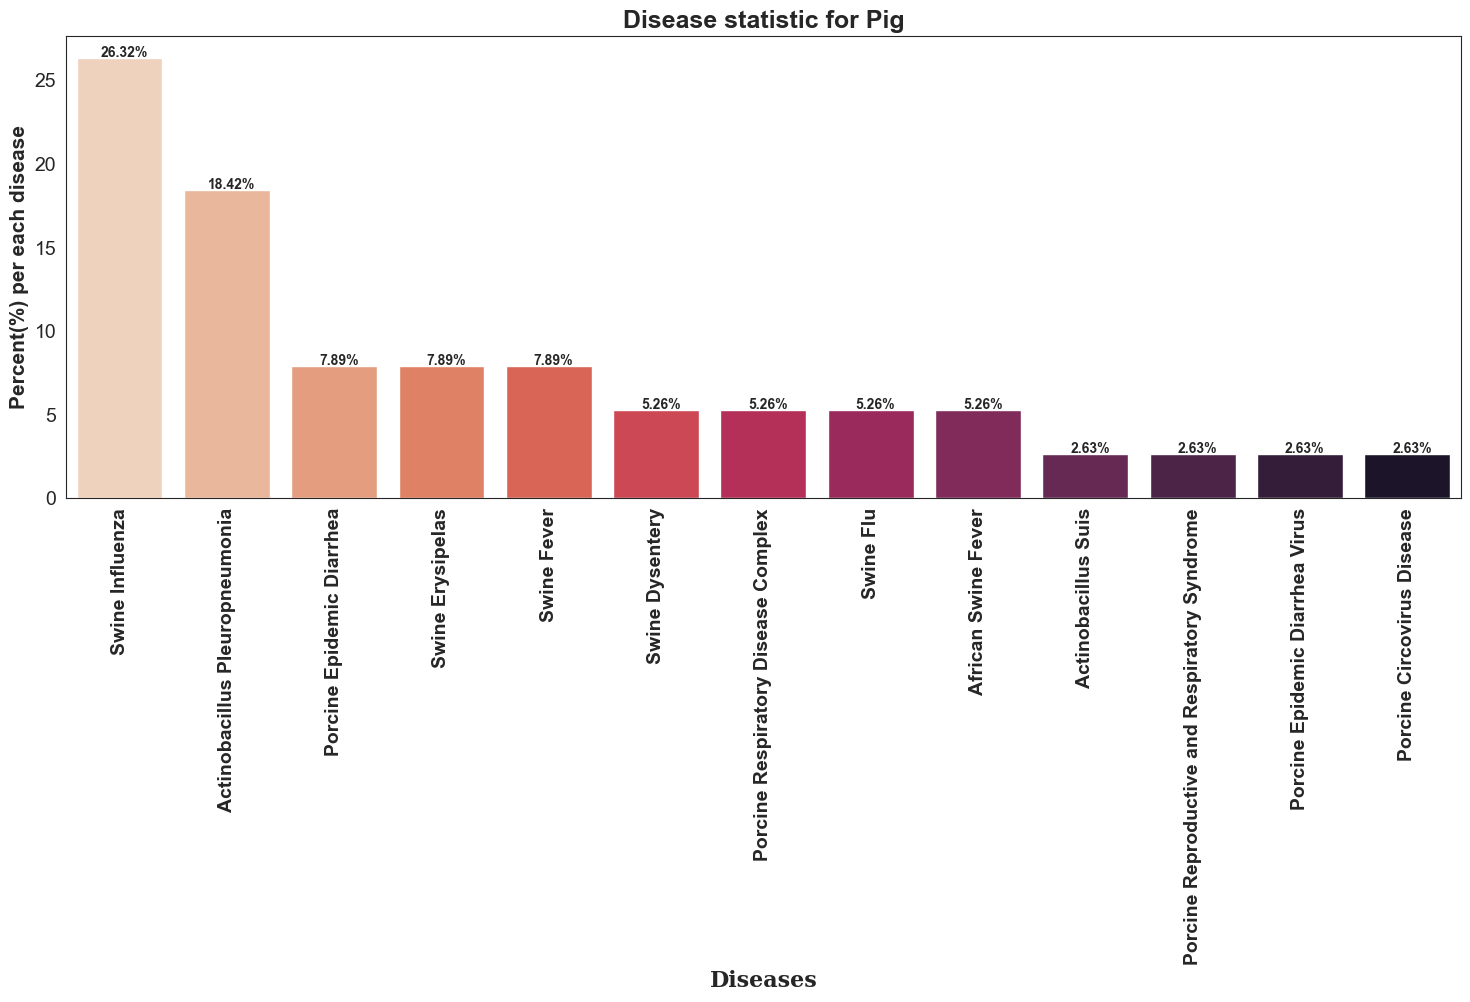

In [1144]:
for animal_type in new_an['Animal_Type'].unique():
    spec = new_an[new_an['Animal_Type'] == animal_type] 
    
    plt.figure(figsize=(18, 6))
    
    ax = sns.countplot(spec, x=spec['Disease_Prediction'], stat='percent', order=spec['Disease_Prediction'].value_counts().sort_values(ascending=False).index, palette='rocket_r')
    disease = np.round(spec['Disease_Prediction'].value_counts() / spec.shape[0] * 100, 2)
    i = 0
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x()
        ax.text(x=x + p.get_width() / 1.8, y=height + 0.1, s=f'{disease.values[i]}%', ha='center', fontsize=10, weight='bold')
        i += 1
    
    plt.xticks(rotation=90, fontsize=14, weight='bold')
    plt.yticks(fontsize=14)
    plt.xlabel('Diseases', fontdict={'fontsize': 16, 'family': 'serif', 'weight': 'bold'})
    plt.ylabel('Percent(%) per each disease', fontsize=15, weight='bold')
    plt.title(f'Disease statistic for {animal_type}', fontsize=18, weight='bold')

    # plt.savefig(f'{animal_type}_disease_stat.png', transparent=True, bbox_inches='tight')
    plt.show()

### Procedure for create correlation matrix

In [1145]:
new_an_copy = new_an.copy()

In [1146]:
new_an_copy['Gender'] = new_an_copy['Gender'].map(lambda x: 1 if x == 'Female' else 0)
new_an_copy.head()

,Animal_Type,Breed,Age,Gender,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,...,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Duration_in_days,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,Dog,Labrador,4,0,25.0,1,1,0,0,0,...,1,0,0,0,0,0,3,120,39.5,Parvovirus
1,Cat,Siamese,2,1,4.5,0,0,0,1,0,...,0,0,0,0,0,0,7,150,38.9,Upper Respiratory Infection
2,Cow,Holstein,3,1,600.0,1,0,0,1,1,...,0,0,0,0,0,0,5,90,40.1,Foot and Mouth Disease
3,Dog,Beagle,1,0,10.0,1,1,1,0,0,...,1,0,0,0,0,0,2,130,39.2,Gastroenteritis
4,Cat,Persian,5,0,3.8,1,0,0,0,0,...,1,0,0,0,0,0,14,160,38.7,Fungal Infection


In [1147]:
diseases = {}
for i, dis in enumerate(new_an_copy['Disease_Prediction'].unique(), start=1):
    diseases[dis] = i

an_types = {}

for i, an in enumerate(new_an_copy['Animal_Type'].unique(), start=1):
    an_types[an] = i


In [1148]:
new_an_copy['Disease_Prediction'] = new_an_copy['Disease_Prediction'].map(lambda x: diseases[x])
new_an_copy['Animal_Type'] = new_an_copy['Animal_Type'].map(lambda x: an_types[x])

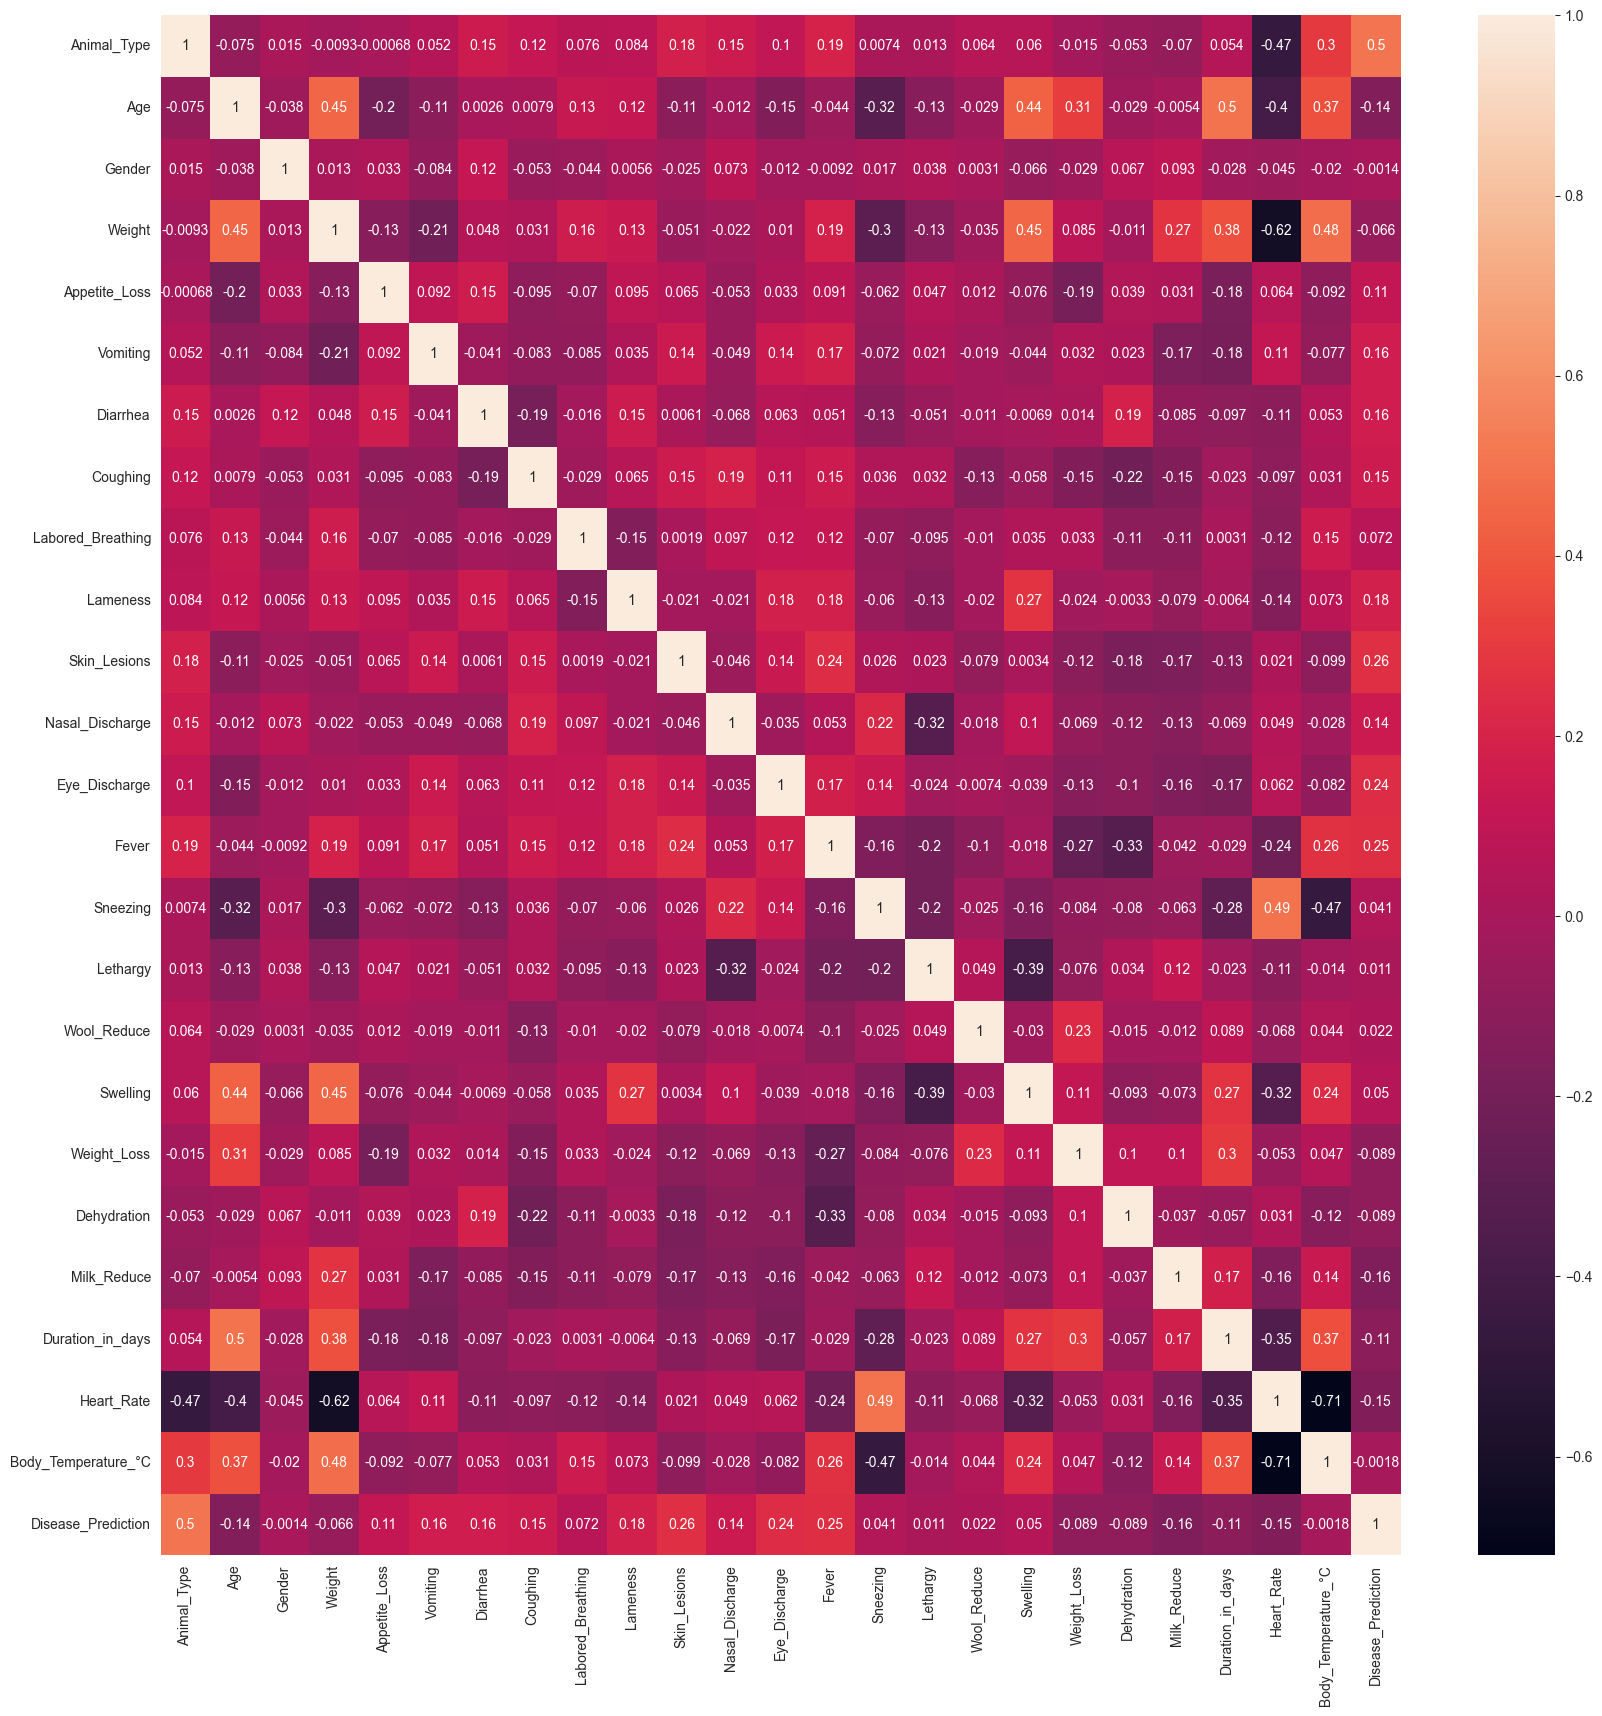

In [1149]:
corr_mat = new_an_copy.corr(numeric_only=True)

plt.figure(figsize=(20, 20))

sns.heatmap(corr_mat, annot=True)
# plt.savefig('correlations.png')
plt.show()

## Drop unnecessary columns 

In [1150]:
new_an.drop(columns=['Gender'], inplace=True)

In [1151]:
new_an.drop(columns=['Duration_in_days'], inplace=True)

## Extend dataset

In [1152]:
def add_new_instances(df):
    '''Function for extension of dataframe of rare instances'''
    
    breeds = df.groupby('Breed')['Breed'].count()
    for b, c in zip(breeds.index, breeds.values):
        if c < 5:
            addit = pd.DataFrame({}, columns=df.columns)
            for _ in range(5):
                addit = pd.concat([addit, df[df['Breed'] == b]], ignore_index=True)
            for _ in range(5):
                inst = df[df['Breed'] == b].iloc[0, :]
                rnd = df.sample(2, random_state=np.random.randint(1, 100))
                rnd['Animal_Type'] = inst['Animal_Type']
                rnd['Breed'] = inst['Breed']
                rnd['Age'] = inst['Age']
                rnd['Weight'] = inst['Weight']
                addit = pd.concat([addit, rnd], ignore_index=True)
            df = pd.concat([df, addit], ignore_index=True)
        else:
            continue
    return df


an_extend = pd.DataFrame({}, columns=new_an.columns)
for animal in new_an['Animal_Type'].unique():
    spec_animal = new_an[new_an['Animal_Type'] == animal]
    new_animals_df = add_new_instances(spec_animal)
    an_extend = pd.concat([an_extend, new_animals_df], ignore_index=True)


an_extend

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Heart_Rate,Body_Temperature_°C,Disease_Prediction
0,Dog,Labrador,4,25.0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,120,39.5,Parvovirus
1,Dog,Beagle,1,10.0,1,1,1,0,0,0,...,0,1,0,0,0,0,0,130,39.2,Gastroenteritis
2,Dog,German Shepherd,3,30.0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,110,39.3,Lyme Disease
3,Dog,Bulldog,5,23.0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,115,40.0,Canine Distemper
4,Dog,Poodle,2,12.0,1,1,0,1,0,0,...,0,1,0,0,0,0,0,115,39.4,Kennel Cough
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Pig,Yorkshire,2,110.0,1,1,1,1,0,1,...,0,1,0,0,0,0,0,105,39.6,Swine Influenza
2107,Pig,Yorkshire,2,110.0,1,1,0,1,1,0,...,0,1,0,0,0,0,0,100,39.2,Swine Dysentery
2108,Pig,Yorkshire,2,110.0,0,1,1,1,1,0,...,0,0,0,0,1,0,0,87,39.8,Actinobacillus Pleuropneumonia
2109,Pig,Yorkshire,2,110.0,1,1,0,1,1,0,...,0,1,0,0,0,0,0,95,39.1,Swine Influenza


In [1153]:
an_extend.describe()

,Animal_Type,Breed,Age,Weight,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,...,Sneezing,Lethargy,Wool_Reduce,Swelling,Weight_Loss,Dehydration,Milk_Reduce,Heart_Rate,Body_Temperature_°C,Disease_Prediction
count,2111,2111,2111,2111.0,2111,2111,2111,2111,2111,2111,...,2111,2111,2111,2111,2111,2111,2111,2111,2111.0,2111
unique,8,120,16,110.0,2,2,2,2,2,2,...,2,2,2,2,2,2,2,61,19.0,139
top,Horse,Dachshund,4,95.0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,80,39.4,Bovine Tuberculosis
freq,345,34,404,94.0,2055,1292,1187,1708,1206,1436,...,1871,1388,2102,1714,1918,2024,2071,192,291.0,85


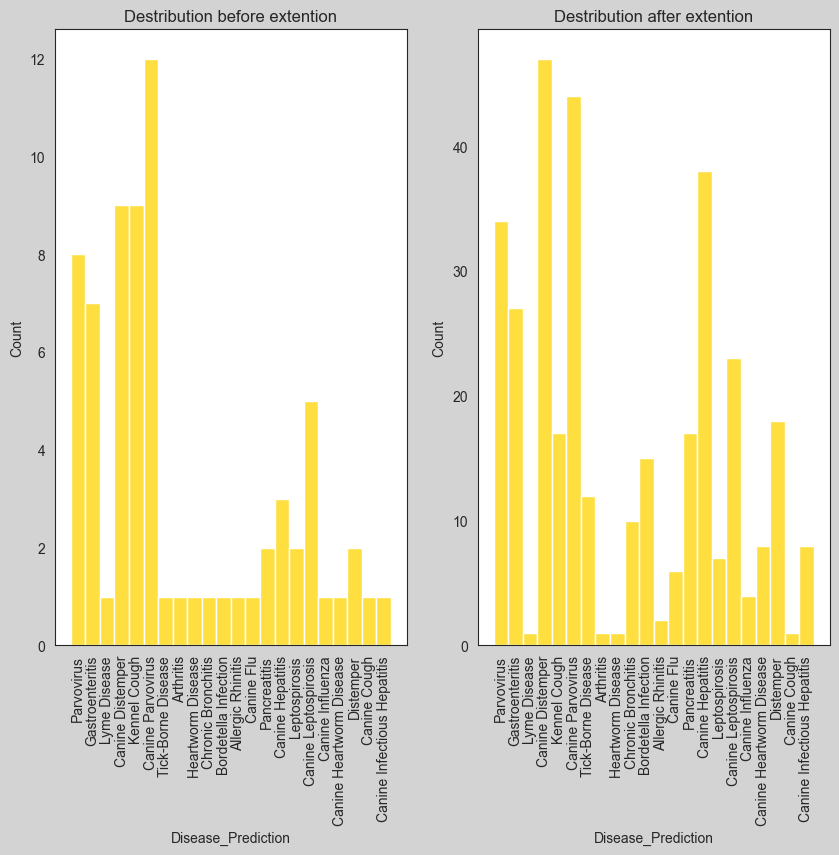

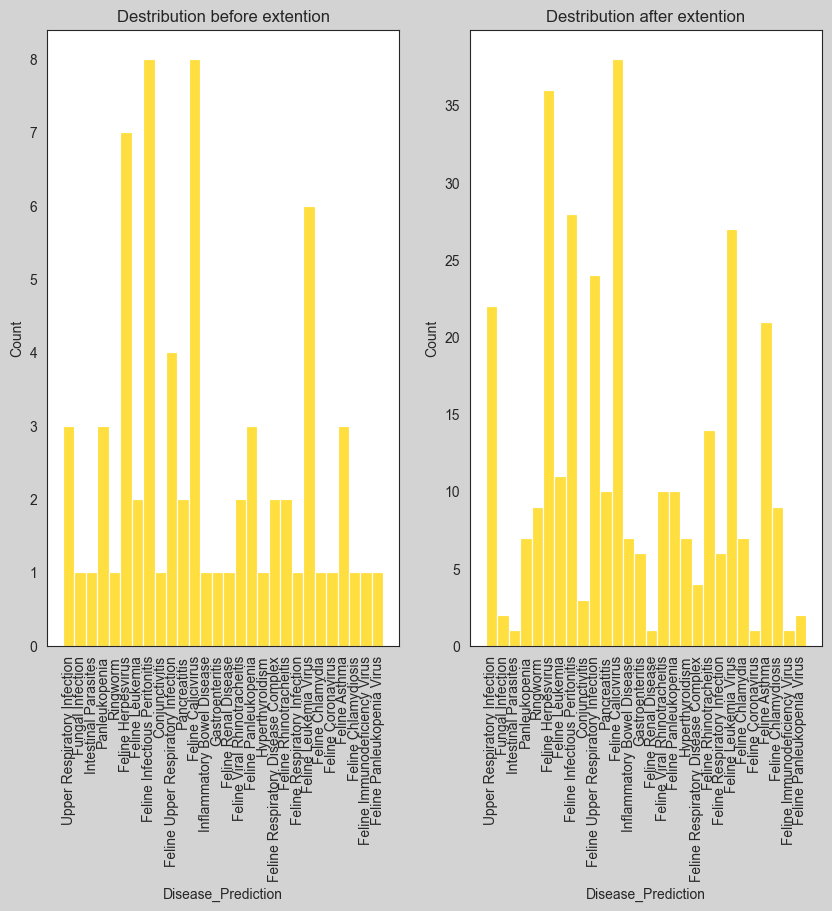

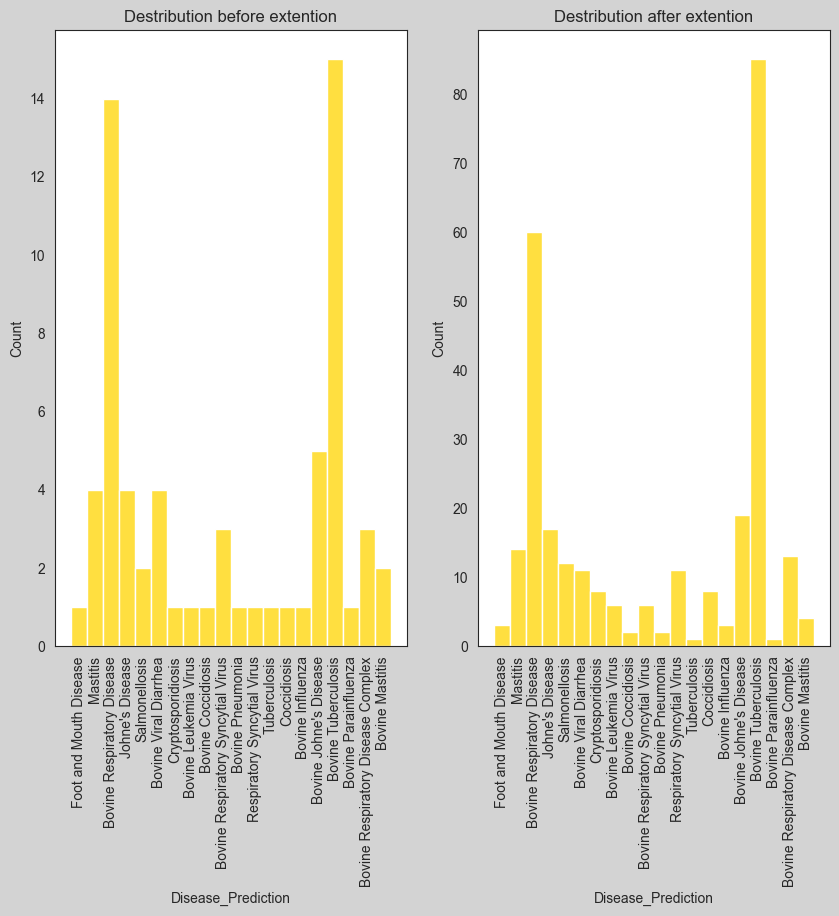

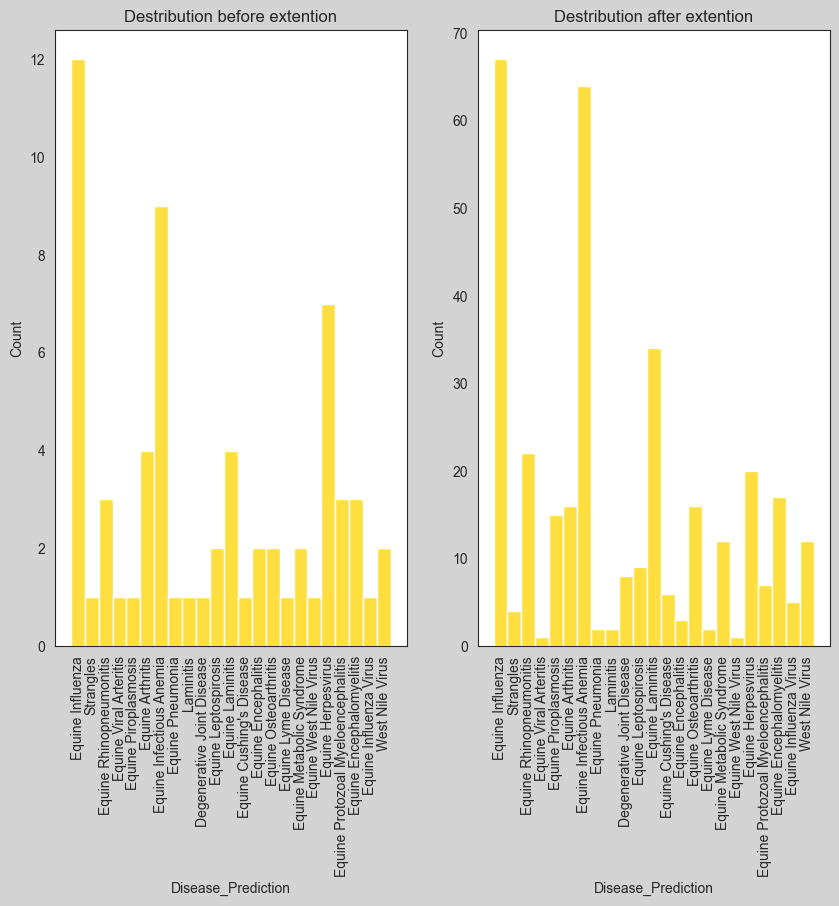

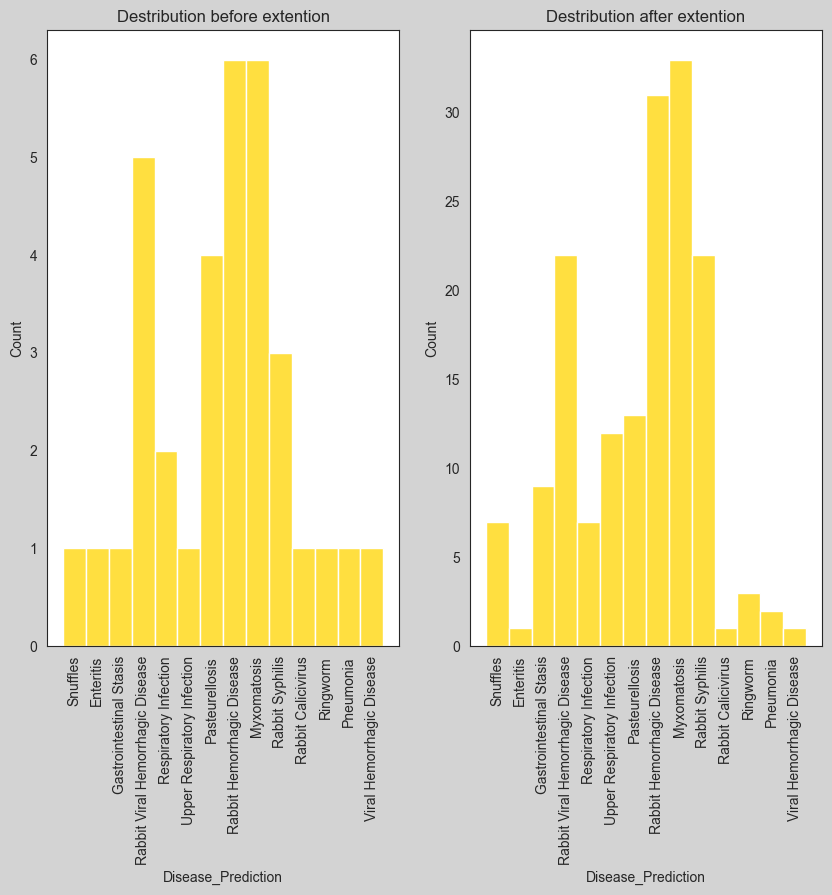

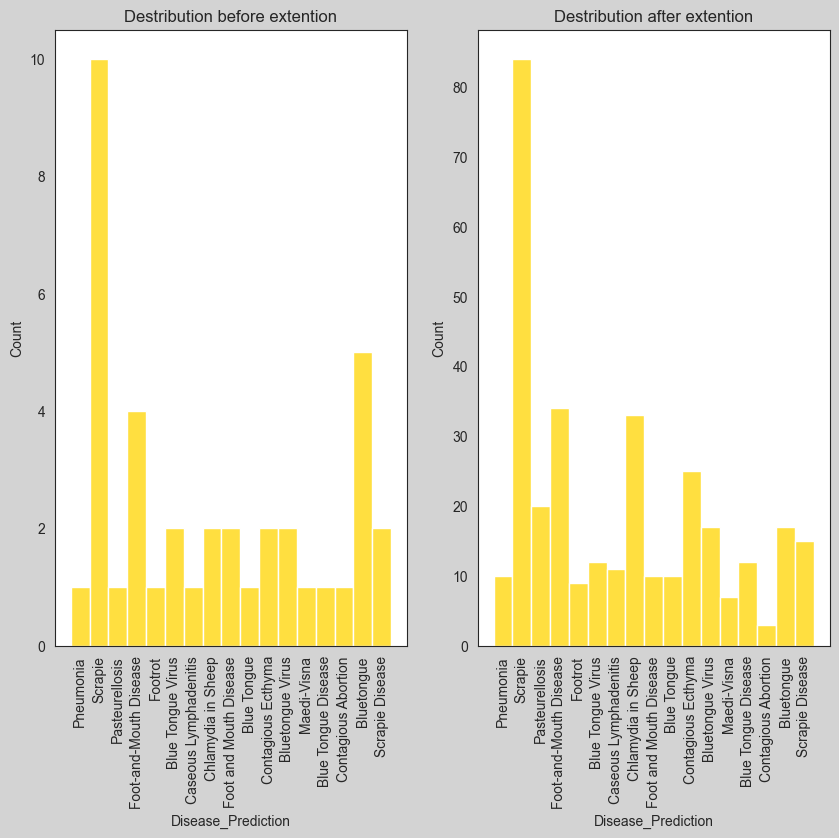

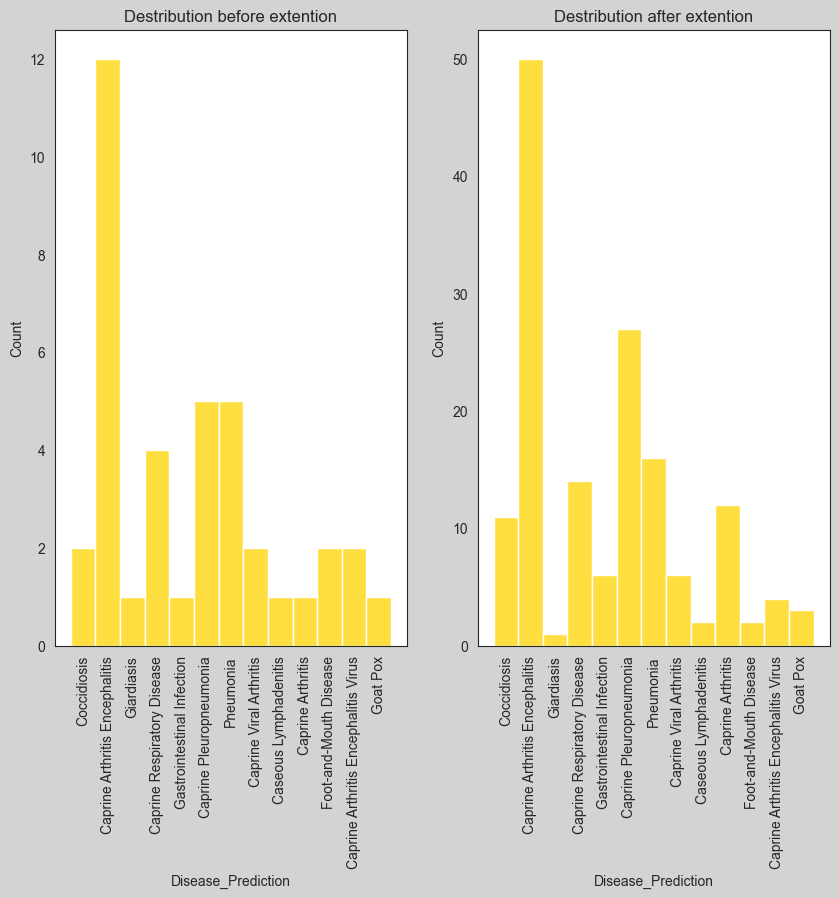

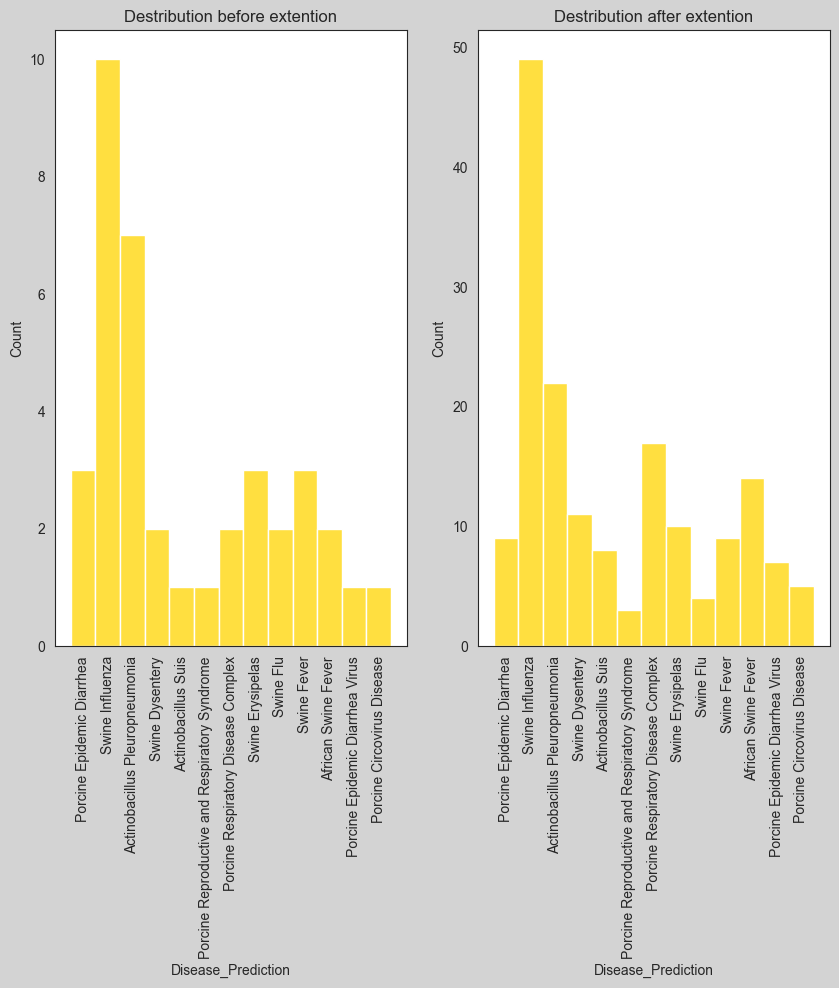

In [1154]:

for animal_type in new_an['Animal_Type'].unique():
    before = new_an[new_an['Animal_Type'] == animal_type]
    after = an_extend[an_extend['Animal_Type'] == animal_type]
    
    plt.figure(figsize=(10, 8), facecolor='lightgrey')
    
    plt.subplot(1, 2, 1)
    
    sns.histplot(before, x='Disease_Prediction', discrete=True)
    plt.xticks(rotation=90)
    plt.title('Destribution before extention')
    
    plt.subplot(1, 2, 2)
    
    sns.histplot(after, x='Disease_Prediction', discrete=True)
    plt.xticks(rotation=90)
    plt.title('Destribution after extention')
    
    plt.show()

### Transform target column into numerical type

In [1155]:
disease_rank = {}
diseases = an_extend['Disease_Prediction'].unique()
for i in range(len(diseases)):
    disease_rank[diseases[i]] = i + 1
disease_rank    

{'Parvovirus': 1,
 'Gastroenteritis': 2,
 'Lyme Disease': 3,
 'Canine Distemper': 4,
 'Kennel Cough': 5,
 'Canine Parvovirus': 6,
 'Tick-Borne Disease': 7,
 'Arthritis': 8,
 'Heartworm Disease': 9,
 'Chronic Bronchitis': 10,
 'Bordetella Infection': 11,
 'Allergic Rhinitis': 12,
 'Canine Flu': 13,
 'Pancreatitis': 14,
 'Canine Hepatitis': 15,
 'Leptospirosis': 16,
 'Canine Leptospirosis': 17,
 'Canine Influenza': 18,
 'Canine Heartworm Disease': 19,
 'Distemper': 20,
 'Canine Cough': 21,
 'Canine Infectious Hepatitis': 22,
 'Upper Respiratory Infection': 23,
 'Fungal Infection': 24,
 'Intestinal Parasites': 25,
 'Panleukopenia': 26,
 'Ringworm': 27,
 'Feline Herpesvirus': 28,
 'Feline Leukemia': 29,
 'Feline Infectious Peritonitis': 30,
 'Conjunctivitis': 31,
 'Feline Upper Respiratory Infection': 32,
 'Feline Calicivirus': 33,
 'Inflammatory Bowel Disease': 34,
 'Feline Renal Disease': 35,
 'Feline Viral Rhinotracheitis': 36,
 'Feline Panleukopenia': 37,
 'Hyperthyroidism': 38,
 'Feli

In [1156]:
an_extend['Disease_Prediction'] = an_extend['Disease_Prediction'].map(func=lambda x: disease_rank[x])


In [1157]:
an_extend.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Animal_Type          2111 non-null   object
 1   Breed                2111 non-null   object
 2   Age                  2111 non-null   object
 3   Weight               2111 non-null   object
 4   Appetite_Loss        2111 non-null   object
 5   Vomiting             2111 non-null   object
 6   Diarrhea             2111 non-null   object
 7   Coughing             2111 non-null   object
 8   Labored_Breathing    2111 non-null   object
 9   Lameness             2111 non-null   object
 10  Skin_Lesions         2111 non-null   object
 11  Nasal_Discharge      2111 non-null   object
 12  Eye_Discharge        2111 non-null   object
 13  Fever                2111 non-null   object
 14  Sneezing             2111 non-null   object
 15  Lethargy             2111 non-null   object
 16  Wool_Reduce      

In [1158]:
categorical = ['Animal_Type', 'Breed']
ints = [x for x in an_extend.iloc[:, 2:23].columns if x not in ('Weight', 'Body_Temperature_°C')]
floats = ['Weight', 'Body_Temperature_°C']

for c in categorical:
    an_extend[c] = an_extend[c].astype('str')

for i in ints:
    an_extend[i] = an_extend[i].astype('int64')

for f in floats:
    an_extend[f] = an_extend[f].astype('float64')


In [1159]:
an_extend.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Animal_Type          2111 non-null   str    
 1   Breed                2111 non-null   str    
 2   Age                  2111 non-null   int64  
 3   Weight               2111 non-null   float64
 4   Appetite_Loss        2111 non-null   int64  
 5   Vomiting             2111 non-null   int64  
 6   Diarrhea             2111 non-null   int64  
 7   Coughing             2111 non-null   int64  
 8   Labored_Breathing    2111 non-null   int64  
 9   Lameness             2111 non-null   int64  
 10  Skin_Lesions         2111 non-null   int64  
 11  Nasal_Discharge      2111 non-null   int64  
 12  Eye_Discharge        2111 non-null   int64  
 13  Fever                2111 non-null   int64  
 14  Sneezing             2111 non-null   int64  
 15  Lethargy             2111 non-null   int64  
 16 

### Corelation matrix after extension

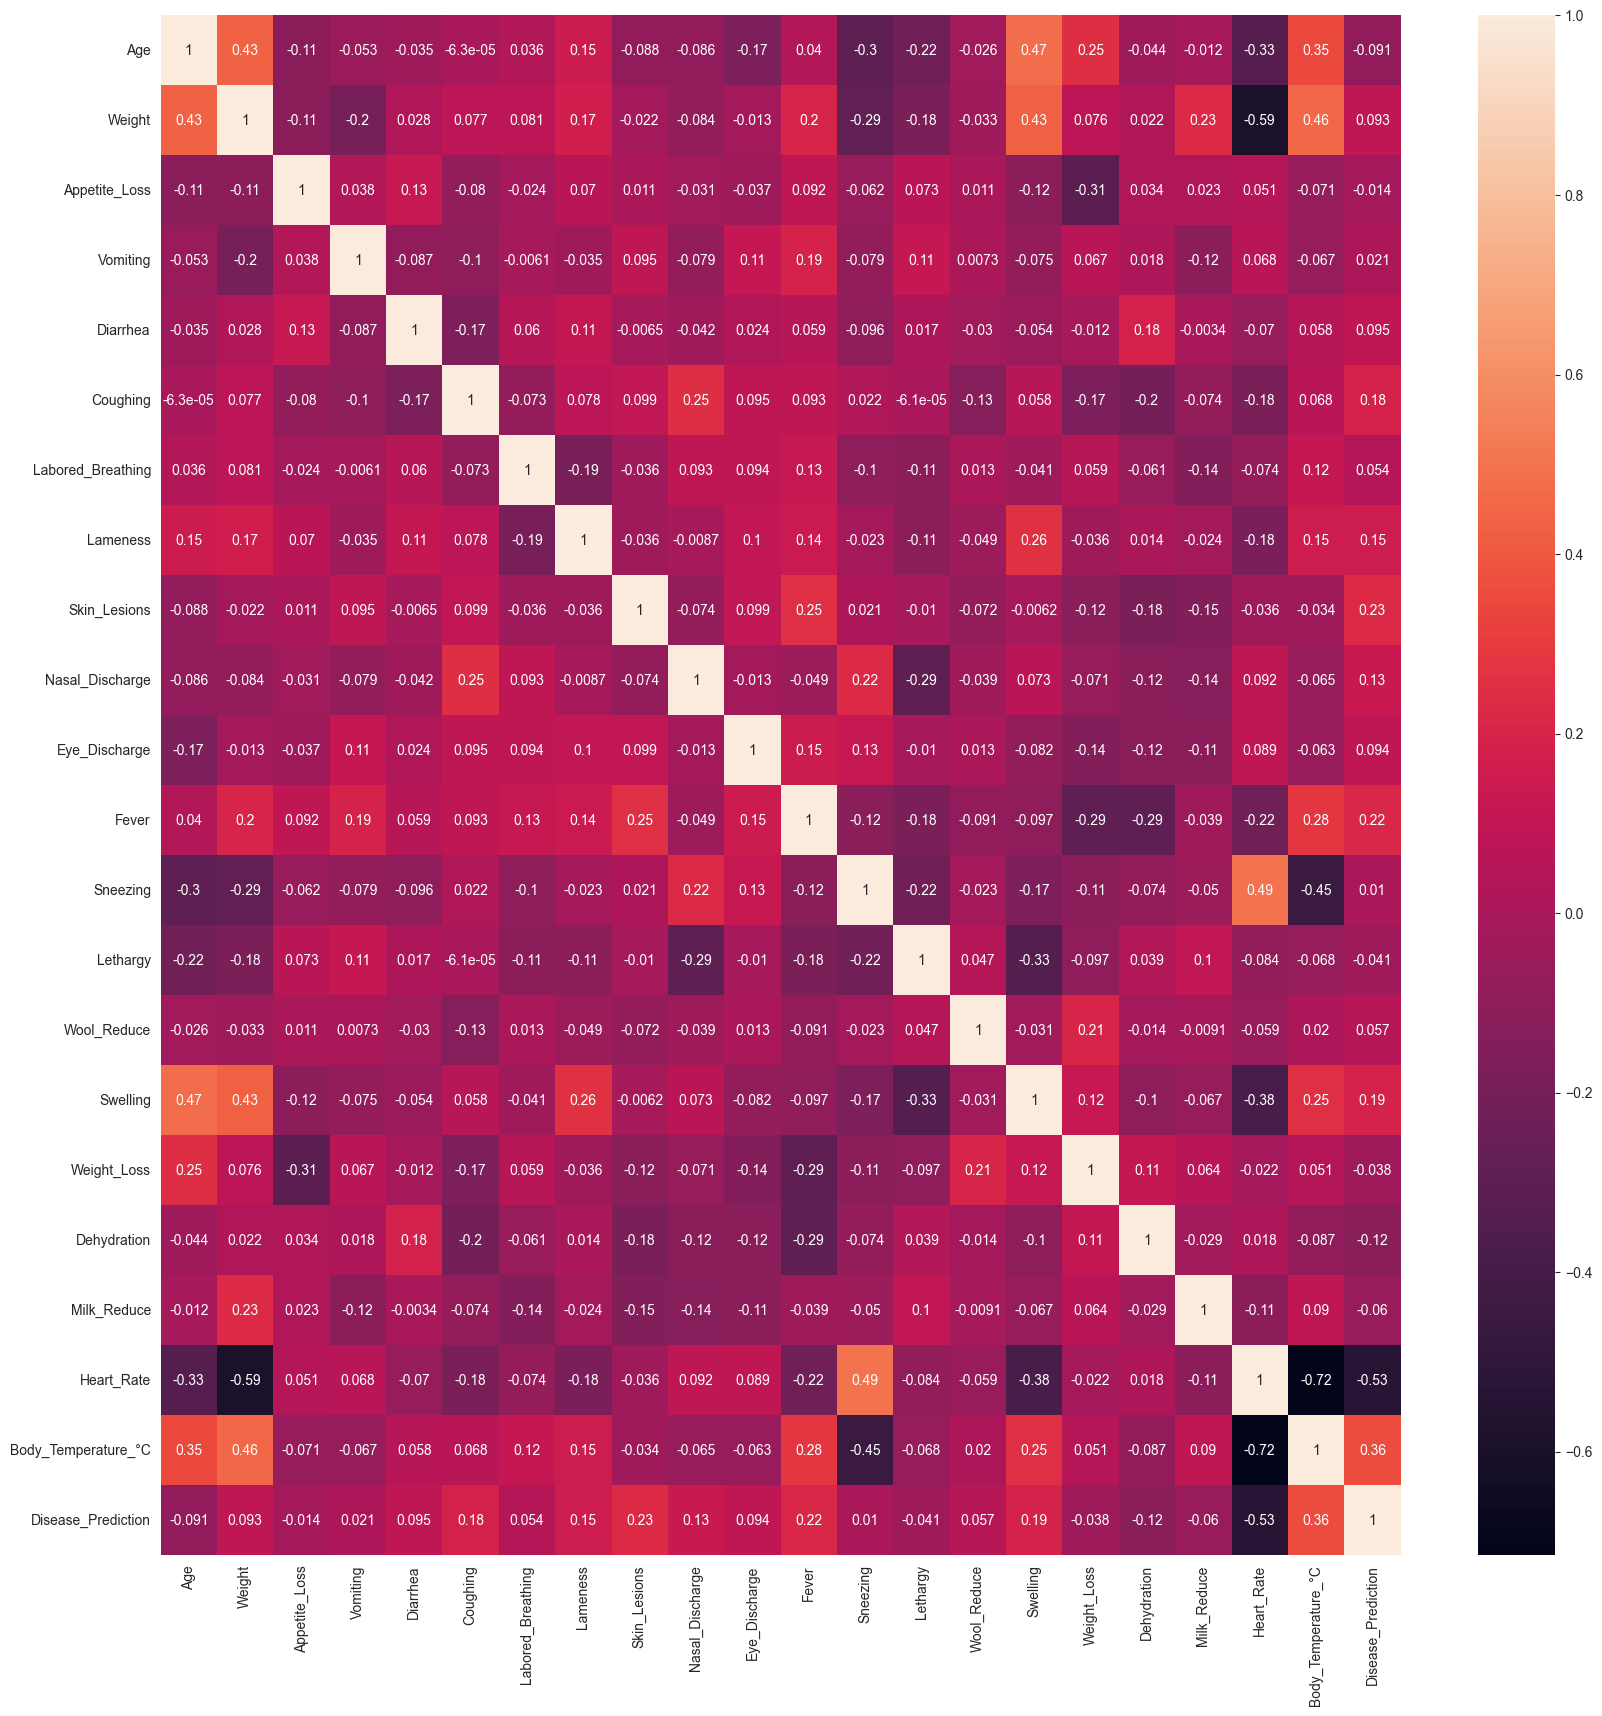

In [1160]:
corr_m = an_extend.corr(numeric_only=True)

plt.figure(figsize=(20, 20))

sns.heatmap(corr_m, annot=True)

plt.show()

## Import necessary libraries

In [1007]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

from transformers import CategoricalImputer, NumericalImputer
from copy import deepcopy

## Split data

In [56]:
Feat = an_extend.drop(columns=['Disease_Prediction'])
target = an_extend['Disease_Prediction']


In [57]:
F_train, F_test, t_train, t_test = train_test_split(Feat, target, test_size=0.2, random_state=187)

In [58]:
F_test.shape

(423, 23)

## Categorical and Numerical columns definition

In [59]:
cat_features = ['Animal_Type', 'Breed']
num_features = ['Age', 'Weight', 'Heart_Rate', 'Body_Temperature_°C']
still_features = [x for x in F_train.drop(columns=['Breed', 'Age', 'Weight', 'Heart_Rate', 'Body_Temperature_°C', 'Animal_Type']).columns]
still_features

['Appetite_Loss',
 'Vomiting',
 'Diarrhea',
 'Coughing',
 'Labored_Breathing',
 'Lameness',
 'Skin_Lesions',
 'Nasal_Discharge',
 'Eye_Discharge',
 'Fever',
 'Dehydration',
 'Sneezing',
 'Weight_Loss',
 'Lethargy',
 'Swelling',
 'Milk_Reduce',
 'Wool_Reduce']

## Custom Imputer for numerical features

In [60]:
# class NumericalImputer(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         self.animals_age = {}
#         self.animals_weight = {}
        
        
#     def fit(self, X, y=None):
#         animals_age = X.groupby('Animal_Type')['Age'].mean().sort_index() 
#         animals_weight = X.groupby('Animal_Type')['Weight'].mean().sort_index()
#         for a, v in zip(animals_age.index, animals_age.values):
#             self.animals_age[a] = v
            
#         for a, v in zip(animals_weight.index, animals_weight.values):
#             self.animals_weight[a] = v
#         return self
  
        
#     def transform(self, X, y=None):
#         X_c = X.copy()
#         for col in X_c.select_dtypes(include='number').columns:
#             if col == 'Age':
#                 X_c.fillna({f'{col}': X_c['Animal_Type'].map(func=lambda x: np.round(self.animals_age[x]))}, inplace=True)
#                 continue
#             elif col == 'Weight':
#                 X_c.fillna({f'{col}': X_c['Animal_Type'].map(func=lambda x: np.round(self.animals_weight[x], decimals=1))}, inplace=True)
#                 continue
#             else:
#                 X_c.fillna({f'{col}': np.round(X_c[col].mean())}, inplace=True)
#                 continue
#         self.get_feature_names_out = lambda x: [x for x in X_c.select_dtypes(include='number').columns]
#         return X_c[[x for x in X_c.select_dtypes(include='number').columns]]

    


# imputer = NumericalImputer()

# test = new_an.sample(15, random_state=66)
# test = test.loc[:, ['Age', 'Weight', 'Heart_Rate', 'Body_Temperature_°C', 'Animal_Type']]
# imputer.fit(test)
# test

## Custom Imputer for categorical features

In [63]:
# class CategoricalImputer(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         self.animals = {}
#         self.data = None

#     def fit(self, X, y=None):
#         self.data = X.groupby('Animal_Type')['Breed'].value_counts()
#         for a, b in self.data.index:
#             if a not in self.animals:
#                 self.animals[a] = [b]
#                 continue
#             else:
#                 self.animals[a].append(b)
#                 continue
#         return self

#     def search_by_breed(self, breed):
#         animal = 'Unknown'
#         for a, brds in self.animals.items():
#             if breed in brds:
#                 animal = a
#                 break
#         return animal
    
#     def transform(self, X, y=None):
#         X_c = X.copy()
#         for col in X_c.columns:
#             if col == 'Animal_Type':
#                 X_c.loc[X_c[col].isna(), col] = X_c.loc[X_c[col].isna(), 'Breed'].apply(func=self.search_by_breed)
#             else:
#                 X_c.loc[X_c[col].isna(), col] = X_c.loc[X_c[col].isna(), 'Animal_Type'].apply(func=lambda x: self.animals[x][0])
#         self.get_feature_names_out = lambda x: [x for x in X_c.columns]
#         return X_c

## Pipelines for preprocessing data

In [64]:
first_pipe = Pipeline(steps=[('categorical', CategoricalImputer()), ('numerical', NumericalImputer())])


cat_pipe = Pipeline(steps=[('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])
num_pipe = Pipeline(steps=[('scale', RobustScaler())])
still_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0))])

In [65]:
preprocessor = ColumnTransformer(transformers=[('still', still_pipe, still_features), ('categorical', cat_pipe, cat_features), ('numerical', num_pipe, num_features)])

In [66]:
gen_pipe = Pipeline(steps=[('impute', first_pipe), ('preproc', preprocessor)])

## Whole pipeline test

In [67]:
trs = gen_pipe.fit_transform(F_train)

In [68]:
df = pd.DataFrame(trs, columns=gen_pipe.get_feature_names_out())
df.head()

,still__Appetite_Loss,still__Vomiting,still__Diarrhea,still__Coughing,still__Labored_Breathing,still__Lameness,still__Skin_Lesions,still__Nasal_Discharge,still__Eye_Discharge,still__Fever,...,categorical__Breed_Toggenburg,categorical__Breed_Tunis,categorical__Breed_Welsh Pony,categorical__Breed_Wessex Saddleback,categorical__Breed_Yorkshire,categorical__Breed_Yorkshire Terrier,numerical__Age,numerical__Weight,numerical__Heart_Rate,numerical__Body_Temperature_°C
0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.273305,0.30,0.25
1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.333333,-0.152542,0.70,-0.25
2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,-0.157839,1.04,-2.00
3,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.666667,0.055085,-0.12,-0.75
4,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.468220,-0.10,0.75


In [69]:
res = preprocessor.fit_transform(F_train)
res_df = pd.DataFrame(res, columns=[x.split('__')[1] for x in preprocessor.get_feature_names_out()])
res_df.head()

,Appetite_Loss,Vomiting,Diarrhea,Coughing,Labored_Breathing,Lameness,Skin_Lesions,Nasal_Discharge,Eye_Discharge,Fever,...,Breed_Toggenburg,Breed_Tunis,Breed_Welsh Pony,Breed_Wessex Saddleback,Breed_Yorkshire,Breed_Yorkshire Terrier,Age,Weight,Heart_Rate,Body_Temperature_°C
0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.273305,0.30,0.25
1,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.333333,-0.152542,0.70,-0.25
2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,-0.157839,1.04,-2.00
3,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,-0.666667,0.055085,-0.12,-0.75
4,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,0.468220,-0.10,0.75


## RandomForestClassifier

In [89]:
final_pipe = Pipeline(steps=[('preproc', gen_pipe), ('pca', PCA(n_components=20)), ('model', RandomForestClassifier())])
final_pipe.fit(F_train, t_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('preproc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('categorical', ...), ('numerical', ...)]"
,"transform_input 

## RandomForest cross-validation

In [91]:
cross = cross_val_score(final_pipe, F_train, t_train, cv=9, scoring='accuracy')
cross

array([0.90425532, 0.92553191, 0.90425532, 0.89361702, 0.92021277,
       0.92513369, 0.90909091, 0.9144385 , 0.92513369])

## GridSearchCV

In [73]:
RandomForestClassifier()

params = {
    'model__n_estimators': [20, 50, 100, 200],
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [3, 5, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_leaf_nodes': [None, 3, 5],
    'model__class_weight': ['balanced', 'balanced_subsample', None],
         }

forest_grid = GridSearchCV(final_pipe, param_grid=params, scoring='accuracy', cv=2, verbose=1)
forest_grid.fit(F_train, t_train)

Fitting 2 folds for each of 972 candidates, totalling 1944 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [3, 5, ...], 'model__max_leaf_nodes': [None, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher,

In [74]:
print(f'Best params: {forest_grid.best_params_}')
print(f'Best score: {forest_grid.best_score_}')

Best params: {'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_leaf_nodes': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best score: 0.8755924170616114


In [75]:
forest_model = forest_grid.best_estimator_
pred = forest_model.predict(F_test)
acc = accuracy_score(t_test, pred)
acc

0.9101654846335697

## Model evaluation

In [81]:
precision = precision_score(t_test, pred, average='micro')
recall = recall_score(t_test, pred, average='micro')
f1 = f1_score(t_test, pred, average='micro')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

Precision: 0.9101654846335697
Recall: 0.9101654846335697
F1 score: 0.9101654846335697


In [82]:
precision = precision_score(t_test, pred, average='macro', zero_division=np.nan)
recall = recall_score(t_test, pred, average='macro', zero_division=np.nan)
f1 = f1_score(t_test, pred, average='macro', zero_division=np.nan)
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

Precision: 0.9156795321081036
Recall: 0.8961450940100393
F1 score: 0.8740914012155843


In [72]:
confuse = confusion_matrix(t_test, pred)

## DecisionTree

In [576]:
dectree_pipe = Pipeline(steps=[('peprocessing', gen_pipe), ('pca', PCA(n_components=40)), ('model', DecisionTreeClassifier())])
dectree_pipe.fit(F_train, t_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('peprocessing', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('preproc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('categorical', ...), ('numerical', ...)]"
,"transform_i

In [577]:
pred = dectree_pipe.predict(F_test)
accuracy_score(t_test, pred)

0.7754137115839244

## DecisionTree cross-validation

In [578]:
cross_val_score(dectree_pipe, F_train, t_train, scoring='accuracy', cv=5)

array([0.74852071, 0.76627219, 0.79881657, 0.76261128, 0.75964392])

## GridSearchCV

In [579]:
DecisionTreeClassifier()
tree_params = {
    'model__criterion': ["gini", "entropy", "log_loss"],
    'model__splitter': ["best", "random"],
    'model__max_depth': [2, 3, 5, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', None],
}

tree_grid = GridSearchCV(dectree_pipe, param_grid=tree_params, scoring='accuracy', cv=4)
tree_grid.fit(F_train, t_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', None], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: intControls the verbosity: the higher, the more messages.- 

In [580]:
print(f'Best params:{tree_grid.best_params_}')
print(f'Best score:{tree_grid.best_score_}')

Best params:{'model__class_weight': 'balanced', 'model__criterion': 'log_loss', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__splitter': 'random'}
Best score:0.7979857819905213


In [581]:
dectree_model = tree_grid.best_estimator_
pred = dectree_model.predict(F_test)
accuracy_score(t_test, pred)

0.75177304964539

## KNN

In [179]:
knn = Pipeline(steps=[('preproc', preprocessor), ('pca', PCA(n_components=20)), ('model', KNeighborsClassifier())])
knn.fit(F_train, t_train)
pred = knn.predict(F_test)
accuracy_score(t_test, pred)

0.8156028368794326

In [173]:
knn_params = {'model__n_neighbors': [2, 3, 5, 8, 9],
             'model__weights': ['uniform', 'distance'],
             'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
             'model__p': [1, 2, 4]}

knn_grid = GridSearchCV(knn, param_grid=knn_params, scoring='accuracy', cv=6)
knn_grid.fit(F_train, t_train)

C:\Users\Lenovo\Desktop\DANKURSES\Final_project\final\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=6.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__algorithm': ['auto', 'ball_tree', ...], 'model__n_neighbors': [2, 3, ...], 'model__p': [1, 2, ...], 'model__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",6
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [174]:
print(f'Params: {knn_grid.best_params_}')
print(f'Score: {knn_grid.best_score_}')

Params: {'model__algorithm': 'auto', 'model__n_neighbors': 2, 'model__p': 1, 'model__weights': 'distance'}
Score: 0.9052291293337708


In [180]:
knn_model = knn_grid.best_estimator_
pred = knn_model.predict(F_test)
accuracy_score(t_test, pred)

0.8817966903073287

## LogRegression, LinearSVM, SVM

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC

In [ ]:
svc = Pipeline(steps=[('preproc', preprocessor), ('pca', PCA(n_components=20)), ('model', SVC())])
line_svc = Pipeline(steps=[('preproc', preprocessor), ('pca', PCA(n_components=20)), ('model', LinearSVC())])
logistic = Pipeline(steps=[('preproc', preprocessor), ('pca', PCA(n_components=20)), ('model', LogisticRegression())])
svc.fit(F_train, t_train)
line_svc.fit(F_train, t_train)
logistic.fit(F_train, t_train)

In [184]:
svc_pred = svc.predict(F_test)
line_svc_pred = line_svc.predict(F_test)
log_pred = logistic.predict(F_test)
print(f'SVC: {accuracy_score(t_test, svc_pred)}')
print(f'LinearSVC: {accuracy_score(t_test, line_svc_pred)}')
print(f'LogisticRegr: {accuracy_score(t_test, log_pred)}')

SVC: 0.8014184397163121
LinearSVC: 0.7919621749408984
LogisticRegr: 0.7446808510638298


In [ ]:
print(f'Best params: {grid_s.best_params_}')
print(f'Best score: {grid_s.best_score_}')

## Import libraries for bufferization models

In [76]:
import joblib
import pickle

In [77]:
# joblib.dump(forest_model, 'ForestClassifier.joblib')
# joblib.dump(disease_rank, 'disease_names.joblib')

In [78]:
# with open('ForestCls.pkl', 'wb') as f:
#     pickle.dump(forest_model, f)

In [79]:
import dill

In [80]:
with open('Forest_2.pkl', 'wb') as f:
    dill.dump(forest_model, f)

In [191]:
with open('KNN.pkl', 'wb') as k:
    dill.dump(knn_model, k)

In [568]:
with open('DecisionTree.pkl', 'wb') as t:
    dill.dump(dectree_model, t)